# Apply `policlim` to Colombian manifestos: 2022 and 2026

This notebook collects the presidential manifesto PDFs for the **2022** and **2026** elections, extracts their text, classifies sentence-level text with [`marysanford/policlim`](https://huggingface.co/marysanford/policlim), and reports manifesto-level climate-salience shares.

The two election years are processed and stored **separately** (`output/manifestos/policlim_2022/` and `.../policlim_2026/`). They are pooled only in the final comparison section, so that candidates can be compared within a year and across years on a common scale.

PDFs are read only from the local folder `data/manifestos/raw/<year>/`. Nothing is downloaded: the files on disk are the corpus, so adding, replacing or removing a PDF there is the only way to change what is analysed.

A candidate's programme may be published as several PDFs. Files whose names resolve to the same entry in `MANIFESTO_META` are merged into one document before classification, so each candidate contributes a single manifesto-level share; the constituent filenames are kept in the `source_files` column.

The model was developed for political manifesto text. Its authors recommend manually validating samples of predictions, especially when applying it to a new source or language.

In [14]:
%pip install -q pandas pypdf torch transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
from pypdf import PdfReader
from transformers import pipeline

NOTEBOOK_NAME = "apply_policlim_to_manifestos_2022_2026.ipynb"

# VS Code may start the notebook kernel outside the project directory.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / NOTEBOOK_NAME).exists():
    notebook_project = Path.home() / "Dropbox" / "Green_Backlash_Colombia"
    if (notebook_project / NOTEBOOK_NAME).exists():
        PROJECT_ROOT = notebook_project

# The two election years are kept in separate folders throughout; they are pooled
# only in the comparison section at the end of the notebook.
YEARS = ["2022", "2026"]

RAW_ROOT = PROJECT_ROOT / "raw"
OUTPUT_ROOT = PROJECT_ROOT / "output"
PDF_DIRS = {year: RAW_ROOT / year for year in YEARS}
OUTPUT_DIRS = {year: OUTPUT_ROOT / f"policlim_{year}" for year in YEARS}
COMPARISON_DIR = OUTPUT_ROOT / "policlim_comparison"
for directory in [*PDF_DIRS.values(), *OUTPUT_DIRS.values(), COMPARISON_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_ID = "marysanford/policlim"

print(f"Project root: {PROJECT_ROOT}")
for year in YEARS:
    print(f"{year}: PDFs in {PDF_DIRS[year]} -> outputs in {OUTPUT_DIRS[year]}")
print(f"Cross-year comparison outputs: {COMPARISON_DIR}")

Project root: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos
2022: PDFs in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\raw\2022 -> outputs in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_2022
2026: PDFs in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\raw\2026 -> outputs in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_2026
Cross-year comparison outputs: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison


In [16]:
def collect_year(year):
    """Return one record per PDF found locally for `year`.

    The local folder is the single source of truth: nothing is fetched from a remote
    repository, so the corpus is exactly what sits in `data/manifestos/raw/<year>/`.
    """
    return [
        {
            "year": year,
            "filename": pdf_path.name,
            "local_path": str(pdf_path),
            "size_bytes": pdf_path.stat().st_size,
            "modified": pd.Timestamp(pdf_path.stat().st_mtime, unit="s").strftime("%Y-%m-%d %H:%M"),
        }
        for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf"))
    ]


file_manifest = [record for year in YEARS for record in collect_year(year)]
manifest_df = pd.DataFrame(file_manifest)
if manifest_df.empty:
    raise FileNotFoundError(f"No PDFs found for years {YEARS} under {RAW_ROOT}")

# Zero-byte files would silently contribute no sentences; flag them rather than skip them.
empty_files = manifest_df[manifest_df["size_bytes"] == 0]
if not empty_files.empty:
    print("Empty PDF file(s) - remove or replace them:")
    print(empty_files[["year", "filename"]].to_string(index=False), "\n")

for year in YEARS:
    count = int((manifest_df["year"] == year).sum())
    print(f"{year}: {count} manifesto PDF(s) in {PDF_DIRS[year]}")
    if count == 0:
        print(f"  -> place the {year} PDFs there and re-run this cell")

manifest_df


2022: 4 manifesto PDF(s) in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\raw\2022
2026: 6 manifesto PDF(s) in C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\raw\2026


,year,filename,local_path,size_bytes,modified
0,2022,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,3337256,2026-08-29 11:22
1,2022,Programa-de-gobierno-Gustavo-Petro-2022-–-2026...,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,8587694,2026-08-29 11:18
2,2022,resumen-propuestas-sergio-fajardo.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,7380797,2026-08-29 11:26
3,2022,RodolfoHernandez-ProgramaDeGobierno.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,6547840,2026-08-29 11:19
4,2026,Claudia-lopez-Programa-Gobierno-nueva-historia...,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,4630919,2026-08-28 11:44
5,2026,Plan Integrado de Gobierno Final_compressed.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,171568,2026-08-28 11:44
6,2026,Programa-Dignidad-Compromiso.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,311314,2026-08-28 11:44
7,2026,programa-gobierno-2026-2030_cepeda.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,11770787,2026-08-31 14:50
8,2026,Programa_de_gobierno_Abelardo_de_la_Espriella_...,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,2885602,2026-08-31 14:43
9,2026,PROPUESTAS_de_la_Espriella.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,1851004,2026-08-28 11:44


In [17]:
def clean_text(text):
    text = unicodedata.normalize("NFC", text or "")
    text = text.replace("\x00", " ")
    return re.sub(r"\s+", " ", text).strip()


# Some PDFs store text as Latin-1 bytes while declaring Adobe StandardEncoding, so every
# accented character extracts as an unrelated glyph: "climática" arrives as "climÆtica".
# Accent stripping cannot normalise these, so the keyword counts would silently miss any
# term spelled with á or é. The Windows-1252 quotes and dashes are undecoded in the same
# documents and are repaired here too, because the sentence splitter keys on punctuation.
STANDARD_ENCODING_REPAIRS = {
    "Æ": "á", "Ø": "é", "œ": "ú", "æ": "ñ", "˝": "Í", "`": "Á",
    "\x93": "\u201c", "\x94": "\u201d", "\x96": "\u2013", "\x97": "\u2014",
}
_REPAIR_TABLE = str.maketrans(STANDARD_ENCODING_REPAIRS)
_REPAIR_MIN_RATE = 1e-4  # ~1 affected glyph per 10,000 characters


def repair_encoding(text):
    """Undo StandardEncoding mis-decoding, but only in documents that clearly show it.

    The substitutions are applied per document rather than unconditionally, so that an
    isolated legitimate "Ø" or backtick in an unaffected manifesto is left as it is.
    """
    if not text:
        return text
    hits = sum(text.count(glyph) for glyph in STANDARD_ENCODING_REPAIRS)
    if hits / len(text) < _REPAIR_MIN_RATE:
        return text
    return text.translate(_REPAIR_TABLE)

def extract_pdf_text(pdf_path):
    reader = PdfReader(str(pdf_path))
    page_text = [clean_text(page.extract_text()) for page in reader.pages]
    # The repair decision is taken on the whole document: single pages are too short for
    # the glyph rate to be a reliable signal.
    document_text = repair_encoding(clean_text(" ".join(page_text)))
    return document_text, len(reader.pages), sum(bool(text) for text in page_text)
 
def split_into_sentences(text):
    # A lightweight splitter keeps the notebook self-contained and works for Spanish punctuation.
    candidates = re.split(r"(?<=[.!?])\s+(?=[A-ZÁÉÍÓÚÜÑ¿¡0-9])|[\r\n]+", text)
    return [sentence.strip() for sentence in candidates if len(sentence.split()) >= 3]

def split_long_sentence(sentence, max_words=350):
    words = sentence.split()
    return [" ".join(words[start:start + max_words]) for start in range(0, len(words), max_words)]


# Map filenames to readable candidate labels and a coarse left-right placement.
# Keys are case-insensitive regexes matched against the filename, so the 2022 entries
# work regardless of the exact filenames used for those PDFs. Unmatched files keep
# their filename stem and are marked "Unclassified" rather than silently mislabelled.
#
# The label is also the merge key: when a candidate's programme is published as more
# than one PDF, every file matching the same pattern is treated as one manifesto.
MANIFESTO_META = [
    # 2026
    (r"programa-gobierno-2026-2030", "Pacto Histórico (Petro's party)", "Left"),
    (r"Programa-Dignidad-Compromiso", "Dignidad y Compromiso", "Left"),
    (r"claudia.?l[oó]pez", "Claudia López", "Center/independent"),
    (r"tigre|espriella", "De la Espriella", "Right"),
    (r"Plan Integrado de Gobierno", "Plan Integrado de Gobierno", "Right"),
    # 2022
    (r"petro|pacto.?hist", "Petro (Pacto Histórico)", "Left"),
    (r"fajardo|centro.?esperanza", "Fajardo (Centro Esperanza)", "Center/independent"),
    (r"betancourt|ox[ií]geno", "Betancourt (Verde Oxígeno)", "Center/independent"),
    (r"guti[eé]rrez|\bfico\b|equipo.?por.?colombia", "Gutiérrez (Equipo por Colombia)", "Right"),
    (r"hern[aá]ndez|rodolfo|liga", "Hernández (Liga Anticorrupción)", "Right"),
    (r"g[oó]mez|salvaci[oó]n", "Gómez (Salvación Nacional)", "Right"),
    (r"john.?milton|justa.?libres", "Rodríguez (Colombia Justa Libres)", "Right"),
]


def match_meta(filename):
    """Return (display label, ideological bloc) for a manifesto filename."""
    for pattern, label, position in MANIFESTO_META:
        if re.search(pattern, filename, flags=re.IGNORECASE):
            return label, position
    return Path(filename).stem, "Unclassified"


In [18]:
# One manifesto can be published as several PDFs. Files whose names resolve to the same
# label in MANIFESTO_META are merged into one document here, before classification, so
# that the manifesto-level share is computed over the candidate's whole programme rather
# than once per file. Sentences are split within each PDF first and only then
# concatenated, so the end of one file is never glued to the start of the next.
# Files are concatenated in filename order; the originating PDF stays in
# `manifesto_file`, so every sentence remains traceable to its source.
sentence_rows = []
sentence_counters = {}
for year in YEARS:
    for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf")):
        manifesto_id, position = match_meta(pdf_path.name)
        text, page_count, pages_with_text = extract_pdf_text(pdf_path)
        expanded_sentences = []
        for sentence in split_into_sentences(text):
            expanded_sentences.extend(split_long_sentence(sentence))

        if not expanded_sentences:
            # Scanned PDFs return no embedded text; they need OCR before they can be scored.
            print(
                f"WARNING {year}/{pdf_path.name}: no text extracted "
                f"({page_count} pages, {pages_with_text} with text) - likely a scanned PDF requiring OCR"
            )

        key = (year, manifesto_id)
        for sentence in expanded_sentences:
            # Sentence numbers run continuously across the files of a merged manifesto.
            sentence_counters[key] = sentence_counters.get(key, 0) + 1
            sentence_rows.append({
                "year": year,
                "manifesto_id": manifesto_id,
                "position": position,
                "manifesto_file": pdf_path.name,
                "manifesto_source_path": str(pdf_path),
                "sentence_number": sentence_counters[key],
                "text": sentence,
            })

sentences_df = pd.DataFrame(sentence_rows)
if sentences_df.empty:
    raise ValueError(f"No sentences extracted from PDFs under {RAW_ROOT}")

# Report the merges explicitly: silently pooling two files would be easy to miss.
files_per_manifesto = sentences_df.groupby(["year", "manifesto_id"])["manifesto_file"].nunique()
merged = files_per_manifesto[files_per_manifesto > 1]
if merged.empty:
    print("No manifesto was assembled from more than one PDF.\n")
else:
    print("Manifestos merged from several PDFs:")
    for (year, manifesto_id), file_count in merged.items():
        parts = sorted(sentences_df.loc[
            (sentences_df["year"] == year) & (sentences_df["manifesto_id"] == manifesto_id),
            "manifesto_file",
        ].unique())
        print(f"  {year}  {manifesto_id}: {file_count} files -> {', '.join(parts)}")
    print()

extraction_overview = sentences_df.groupby("year").agg(
    manifestos=("manifesto_id", "nunique"),
    pdf_files=("manifesto_file", "nunique"),
    sentences=("text", "size"),
)
print(extraction_overview)
sentences_df.head()


Ignoring wrong pointing object 13 0 (offset 0)
Ignoring wrong pointing object 16 0 (offset 0)
Ignoring wrong pointing object 18 0 (offset 0)
Ignoring wrong pointing object 33 0 (offset 0)
Ignoring wrong pointing object 230 0 (offset 0)
Ignoring wrong pointing object 268 0 (offset 0)
Ignoring wrong pointing object 293 0 (offset 0)
Ignoring wrong pointing object 331 0 (offset 0)


Manifestos merged from several PDFs:
  2026  De la Espriella: 2 files -> PROPUESTAS_de_la_Espriella.pdf, Programa_de_gobierno_Abelardo_de_la_Espriella_2026_2030-1.pdf

      manifestos  pdf_files  sentences
year                                  
2022           4          4       2667
2026           5          6       2395


,year,manifesto_id,position,manifesto_file,manifesto_source_path,sentence_number,text
0,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,1,COLOMBIA: UN PAÍS EN ORDEN Y CON OPORTUNIDADES...
1,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,2,"OPORTUNIDADES para que todas las personas, sin..."
2,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,3,"Oportunidades de tener mejor educación, mejore..."
3,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,4,ORDEN Y OPORTUNIDADES para reducir la pobreza ...
4,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,C:\Users\charlott\Dropbox (Personal)\Green_Bac...,5,Nuestro compromiso es liderar a Colombia desde...


In [19]:
# Collapse to unique manifestos per year
manifestos_df = sentences_df.drop_duplicates(subset=['year', 'manifesto_id']).copy()
manifestos_df = manifestos_df[['year', 'manifesto_id']].sort_values(['year', 'manifesto_id']).reset_index(drop=True)

# Separate by year (use string comparison)
data_2022 = manifestos_df[manifestos_df['year'] == '2022'].reset_index(drop=True)
data_2026 = manifestos_df[manifestos_df['year'] == '2026'].reset_index(drop=True)

print(f"2022 manifestos count: {len(data_2022)}")
print(f"2026 manifestos count: {len(data_2026)}")

# Create LaTeX table with side-by-side panels
latex_output = r"""\begin{table}[htbp]
  \centering
  \caption{Party Categorization over time}
    \begin{tabular}{|l|l|}
    \toprule
    \textbf{2022} & \textbf{2026} \\
    \midrule
"""

# Pad to same length
max_len = max(len(data_2022), len(data_2026))

for idx in range(max_len):
    id_2022 = data_2022.iloc[idx]['manifesto_id'] if idx < len(data_2022) else ""
    id_2026 = data_2026.iloc[idx]['manifesto_id'] if idx < len(data_2026) else ""
    
    latex_output += f"    {id_2022} & {id_2026} \\\\\n"

latex_output += r"""    \bottomrule
    \end{tabular}%
  \label{tab:party_categorization}%
\end{table}%
"""

table_output_path = COMPARISON_DIR / "party_table.tex"
with open(table_output_path, 'w', encoding='utf-8') as f:
    f.write(latex_output)

print(f"\nSaved LaTeX table: {table_output_path}")
print("\nTable preview:")
print(latex_output)

2022 manifestos count: 4
2026 manifestos count: 5

Saved LaTeX table: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\party_table.tex

Table preview:
\begin{table}[htbp]
  \centering
  \caption{Party Categorization over time}
    \begin{tabular}{|l|l|}
    \toprule
    \textbf{2022} & \textbf{2026} \\
    \midrule
    Fajardo (Centro Esperanza) & Claudia López \\
    Gutiérrez (Equipo por Colombia) & De la Espriella \\
    Hernández (Liga Anticorrupción) & Dignidad y Compromiso \\
    Petro (Pacto Histórico) & Pacto Histórico (Petro's party) \\
     & Plan Integrado de Gobierno \\
    \bottomrule
    \end{tabular}%
  \label{tab:party_categorization}%
\end{table}%



In [20]:
# Load the published model. The model's config supplies the authoritative label names.
classifier = pipeline(
    task="text-classification",
    model=MODEL_ID,
    tokenizer=MODEL_ID,
    truncation=True,
    max_length=512,
    top_k=None,
)

id2label = classifier.model.config.id2label
print("Model labels:", id2label)

# Resolve the climate-relevant label once, from the config, rather than per sentence.
CLIMATE_LABEL = next(
    (label for label in id2label.values()
     if label.lower().endswith("1") or "climate" in label.lower() or "yes" in label.lower()),
    None,
)
if CLIMATE_LABEL is None:
    raise ValueError(f"Could not identify the climate-relevant label among {list(id2label.values())}")
print("Climate-relevant label:", CLIMATE_LABEL)


def normalise_predictions(batch_predictions):
    # Transformers versions differ slightly in their pipeline return shape.
    if batch_predictions and isinstance(batch_predictions[0], dict):
        batch_predictions = [batch_predictions]
    return batch_predictions


BATCH_SIZE = 32
texts = sentences_df["text"].tolist()
all_predictions = []
for start in range(0, len(texts), BATCH_SIZE):
    all_predictions.extend(
        normalise_predictions(classifier(texts[start:start + BATCH_SIZE], batch_size=BATCH_SIZE))
    )
    if (start // BATCH_SIZE) % 25 == 0:
        print(f"  classified {min(start + BATCH_SIZE, len(texts)):,}/{len(texts):,} sentences", end="\r")
print(f"  classified {len(all_predictions):,}/{len(texts):,} sentences")


def prediction_fields(predictions):
    by_label = {item["label"]: float(item["score"]) for item in predictions}
    top_label = max(by_label, key=by_label.get)
    return top_label, by_label[CLIMATE_LABEL], json.dumps(by_label, ensure_ascii=False)


fields = [prediction_fields(prediction) for prediction in all_predictions]
sentences_df[["predicted_label", "climate_score", "label_scores"]] = pd.DataFrame(fields, index=sentences_df.index)
sentences_df["climate_label"] = CLIMATE_LABEL
sentences_df["climate_relevant"] = sentences_df["predicted_label"] == CLIMATE_LABEL
sentences_df.head()

Device set to use cpu


Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Climate-relevant label: LABEL_1


KeyboardInterrupt: 

In [ ]:
# MANIFESTO_META and match_meta are defined with the other helpers, above, because the
# extraction cell needs them to decide which PDFs belong to the same manifesto.
mapping_rows = []
for year in YEARS:
    for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf")):
        label, position = match_meta(pdf_path.name)
        mapping_rows.append({
            "year": year,
            "position": position,
            "manifesto_id": label,
            "file": pdf_path.name,
        })

mapping_df = pd.DataFrame(mapping_rows)
print(f"{len(mapping_df)} PDF(s) -> {mapping_df[['year', 'manifesto_id']].drop_duplicates().shape[0]} manifesto(s)\n")
display(mapping_df.sort_values(["year", "manifesto_id", "file"]))

unmatched = mapping_df[mapping_df["position"] == "Unclassified"]
if not unmatched.empty:
    print("Files with no MANIFESTO_META entry - they are kept as separate manifestos:")
    print(unmatched[["year", "file"]].to_string(index=False))


10 PDF(s) -> 9 manifesto(s)



,year,position,manifesto_id,file
2,2022,Center/independent,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf
0,2022,Right,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf
3,2022,Right,Hernández (Liga Anticorrupción),RodolfoHernandez-ProgramaDeGobierno.pdf
1,2022,Left,Petro (Pacto Histórico),Programa-de-gobierno-Gustavo-Petro-2022-–-2026...
4,2026,Center/independent,Claudia López,Claudia-lopez-Programa-Gobierno-nueva-historia...
9,2026,Right,De la Espriella,PROPUESTAS_de_la_Espriella.pdf
8,2026,Right,De la Espriella,Programa_de_gobierno_Abelardo_de_la_Espriella_...
6,2026,Left,Dignidad y Compromiso,Programa-Dignidad-Compromiso.pdf
7,2026,Left,Pacto Histórico (Petro's party),programa-gobierno-2026-2030_cepeda.pdf
5,2026,Right,Plan Integrado de Gobierno,Plan Integrado de Gobierno Final_compressed.pdf


In [ ]:
# Aggregate sentence predictions into the manifesto-level share used by policlim.
# The unit of aggregation is the manifesto, not the PDF: a programme split across
# several files contributes one row, with the source files listed for provenance.
summary_df = (
    sentences_df.groupby(["year", "manifesto_id", "position"], as_index=False)
    .agg(
        source_files=("manifesto_file", lambda names: "; ".join(sorted(set(names)))),
        source_documents=("manifesto_file", "nunique"),
        source_paths=("manifesto_source_path", lambda paths: "; ".join(sorted(set(paths)))),
        sentence_count=("text", "size"),
        climate_relevant_sentences=("climate_relevant", "sum"),
        climate_salience_share=("climate_relevant", "mean"),
        mean_climate_score=("climate_score", "mean"),
    )
)
summary_df["label"] = summary_df["manifesto_id"]
summary_df["model_id"] = MODEL_ID
summary_df["model_labels"] = json.dumps(id2label, ensure_ascii=False)

unclassified = summary_df.loc[summary_df["position"] == "Unclassified", ["year", "manifesto_id", "source_files"]]
if not unclassified.empty:
    print("Unlabelled files - add a MANIFESTO_META entry for each, then re-run this cell:")
    print(unclassified.to_string(index=False), "\n")

# Each year is written to its own folder; only the comparison file pools the years.
for year in YEARS:
    year_summary = summary_df[summary_df["year"] == year]
    if year_summary.empty:
        print(f"{year}: no manifestos scored, nothing written")
        continue

    output_dir = OUTPUT_DIRS[year]
    sentence_output = output_dir / f"policlim_{year}_sentence_predictions.csv"
    summary_output = output_dir / f"policlim_{year}_manifesto_summary.csv"
    metadata_output = output_dir / f"policlim_{year}_run_metadata.json"

    sentences_df[sentences_df["year"] == year].to_csv(sentence_output, index=False, encoding="utf-8-sig")
    year_summary.to_csv(summary_output, index=False, encoding="utf-8-sig")
    metadata_output.write_text(json.dumps({
        "year": year,
        "model_id": MODEL_ID,
        "model_labels": id2label,
        "climate_label": CLIMATE_LABEL,
        "source_directory": str(PDF_DIRS[year]),
        "pdfs": [record for record in file_manifest if record["year"] == year],
    }, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"{year}: saved {sentence_output.name}, {summary_output.name}, {metadata_output.name} in {output_dir}")

combined_summary_output = COMPARISON_DIR / "policlim_manifesto_summary_all_years.csv"
summary_df.to_csv(combined_summary_output, index=False, encoding="utf-8-sig")
print(f"Saved combined summary: {combined_summary_output}")

display(
    summary_df[["year", "label", "position", "source_documents", "sentence_count",
                "climate_relevant_sentences", "climate_salience_share"]]
    .sort_values(["year", "climate_salience_share"], ascending=[True, False])
)

KeyError: "Column(s) ['climate_relevant', 'climate_score'] do not exist"

Reopened 2 sentence CSVs, 2 summary CSVs, and 2 metadata JSON files
386/5,062 sentences have climate_score >= 0.8
Saved: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\0.8_score_input_llm.txt
Saved random sample of 25 TEXT records: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\validation\0.8_score_input_llm_sample25.txt


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

position_colors = {
    "Left": "#c83c4a",
    "Right": "#2867a6",
    "Center/independent": "#7a7a7a",
    "Unclassified": "#c9c9c9",
}

years_with_data = [year for year in YEARS if (summary_df["year"] == year).any()]
# One panel per year keeps the elections separate; a shared x-axis makes them comparable.
heights = [max(1, int((summary_df["year"] == year).sum())) for year in years_with_data]
fig, axes = plt.subplots(
    len(years_with_data), 1,
    figsize=(10, 1.2 + 0.75 * sum(heights) + 1.0 * len(years_with_data)),
    sharex=True,
    squeeze=False,
    gridspec_kw={"height_ratios": heights},
)
axes = axes.ravel()

x_max = float(summary_df["climate_salience_share"].max()) * 1.18
for ax, year in zip(axes, years_with_data):
    plot_df = summary_df[summary_df["year"] == year].sort_values("climate_salience_share")
    bars = ax.barh(plot_df["label"], plot_df["climate_salience_share"],
                   color=plot_df["position"].map(position_colors))
    ax.set_title(f"{year} election", loc="left", fontsize=11)
    ax.set_xlim(0, x_max)
    ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, plot_df["climate_salience_share"]):
        ax.text(value + x_max * 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.1%}", va="center")

axes[-1].set_xlabel("Climate-salience share")
fig.suptitle("Climate salience by manifesto, 2022 and 2026 (shared scale)")
used_positions = [p for p in position_colors if (summary_df["position"] == p).any()]
axes[0].legend(
    handles=[Patch(color=position_colors[p], label=p) for p in used_positions],
    loc="lower right",
    frameon=False,
)
fig.tight_layout()
fig.savefig(COMPARISON_DIR / "climate_salience_by_manifesto.png", dpi=200, bbox_inches="tight")
plt.show()

NameError: name 'summary_df' is not defined

## Cross-year comparison: 2022 vs 2026

The two elections are scored independently above. This section is the only place the years are pooled.

Two aggregations are reported because they answer different questions:

- **pooled share** — climate-relevant sentences as a share of all sentences in that year's corpus. Dominated by the longest documents, so it describes the corpus, not the average candidate.
- **mean/median manifesto share** — the per-manifesto shares averaged, so each candidate counts once regardless of document length.

Document lengths differ by an order of magnitude within a year, so the two can move in opposite directions. Read them together, and treat shares from very short documents (a few dozen sentences) as noisy.

In [ ]:
year_comparison = (
    sentences_df.groupby("year")
    .agg(
        manifestos=("manifesto_id", "nunique"),
        pdf_files=("manifesto_file", "nunique"),
        sentences=("text", "size"),
        climate_relevant_sentences=("climate_relevant", "sum"),
        pooled_climate_share=("climate_relevant", "mean"),
    )
    .join(
        summary_df.groupby("year")["climate_salience_share"].agg(
            mean_manifesto_share="mean",
            median_manifesto_share="median",
            min_manifesto_share="min",
            max_manifesto_share="max",
        )
    )
    .reset_index()
)
year_comparison.to_csv(COMPARISON_DIR / "policlim_year_comparison.csv", index=False, encoding="utf-8-sig")
print("Climate salience by election year")
display(year_comparison)

# Mean manifesto share by ideological bloc, to see whether any shift is bloc-specific.
position_comparison = summary_df.pivot_table(
    index="position", columns="year", values="climate_salience_share", aggfunc="mean"
)
position_counts = summary_df.pivot_table(
    index="position", columns="year", values="manifesto_id", aggfunc="count"
)
if position_comparison.shape[1] == 2:
    position_comparison["change"] = position_comparison[YEARS[1]] - position_comparison[YEARS[0]]
position_comparison.to_csv(COMPARISON_DIR / "policlim_position_comparison.csv", encoding="utf-8-sig")
print("\nMean manifesto-level climate salience by bloc (cell counts below)")
display(position_comparison)
display(position_counts)

NameError: name 'sentences_df' is not defined

## Manual validation

Review a random sample of predictions from **both** years before using the aggregate scores substantively. The full sentence text, predicted label, per-label probability, and source manifesto are in each year's `policlim_<year>_sentence_predictions.csv`.

In [ ]:
# Sample within each year so both elections are represented in the manual check.
validation_sample = (
    pd.concat([
        group.sample(min(20, len(group)), random_state=42)
        for _, group in sentences_df.groupby("year")
    ])
    [["year", "manifesto_id", "manifesto_file", "sentence_number", "text", "predicted_label", "climate_score", "label_scores"]]
    .sort_values(["year", "manifesto_id", "sentence_number"])
)
validation_sample.to_csv(COMPARISON_DIR / "policlim_validation_sample.csv", index=False, encoding="utf-8-sig")
display(validation_sample)

,year,manifesto_id,manifesto_file,sentence_number,text,predicted_label,climate_score,label_scores
2447,2022,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf,55,La propuesta completa está disponible aquí: ht...,LABEL_0,0.001151,"{""LABEL_0"": 0.998848557472229, ""LABEL_1"": 0.00..."
2560,2022,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf,168,El medio ambiente será el fundamento de cada i...,LABEL_0,0.000962,"{""LABEL_0"": 0.9990382194519043, ""LABEL_1"": 0.0..."
289,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,290,Trabajaremos para que Colombia pase de tener u...,LABEL_0,0.000975,"{""LABEL_0"": 0.9990247488021851, ""LABEL_1"": 0.0..."
298,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,299,La competencia también será a nivel internacio...,LABEL_0,0.001306,"{""LABEL_0"": 0.9986936450004578, ""LABEL_1"": 0.0..."
521,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,522,Incrementaremos el uso de las energías limpias...,LABEL_1,0.999411,"{""LABEL_1"": 0.9994112253189087, ""LABEL_0"": 0.0..."
532,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,533,Fortaleceremos las acciones contra el robo de ...,LABEL_1,0.999382,"{""LABEL_1"": 0.9993822574615479, ""LABEL_0"": 0.0..."
611,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,612,Realizaremos un acompañamiento permanente a lo...,LABEL_0,0.001163,"{""LABEL_0"": 0.998837411403656, ""LABEL_1"": 0.00..."
655,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,656,"Revisar los límites a la integración vertical,...",LABEL_0,0.000967,"{""LABEL_0"": 0.9990332126617432, ""LABEL_1"": 0.0..."
929,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,930,Mantenimiento e implementación del Estatuto Te...,LABEL_0,0.001642,"{""LABEL_0"": 0.9983575940132141, ""LABEL_1"": 0.0..."
2112,2022,Hernández (Liga Anticorrupción),RodolfoHernandez-ProgramaDeGobierno.pdf,243,El faltante será asumido por el Estado.,LABEL_0,0.000948,"{""LABEL_0"": 0.9990519881248474, ""LABEL_1"": 0.0..."


## Abelardo de la Espriella (2026 only)

De la Espriella stood in 2026 but not in 2022, so his rank and percentile are computed **within the 2026 field only**. Comparing him against a pooled 2022+2026 field would mix two different candidate sets.

His programme is distributed as more than one PDF. Those files were merged into a single document in the extraction cell, so the share below is computed over the combined text; the constituent filenames are printed under `source_files`.


In [ ]:
# De la Espriella's programme arrives as several PDFs, already merged into one document
# by the extraction cell. Ranking is within 2026 only: he did not stand in 2022, so a
# pooled rank would be meaningless.
summary_2026 = summary_df[summary_df["year"] == "2026"]
abelardo_matches = summary_2026[
    summary_2026["manifesto_id"].str.contains("abelardo|espriella|tigre", case=False, na=False)
].copy()
if len(abelardo_matches) != 1:
    raise ValueError(
        "Expected one merged De la Espriella manifesto, found: "
        f"{abelardo_matches['manifesto_id'].tolist()}"
    )

abelardo_id = abelardo_matches.iloc[0]["manifesto_id"]
comparison = summary_2026[["manifesto_id", "label", "source_documents", "climate_salience_share", "sentence_count"]].copy()
comparison["rank"] = comparison["climate_salience_share"].rank(method="min", ascending=False).astype(int)
comparison["percentile"] = comparison["climate_salience_share"].rank(pct=True) * 100
abelardo_row = comparison[comparison["manifesto_id"] == abelardo_id].iloc[0]

print(f"Manifesto: {abelardo_id}")
print(f"Assembled from {int(abelardo_row['source_documents'])} PDF(s): {abelardo_matches.iloc[0]['source_files']}")
print(f"Climate-salience share: {abelardo_row['climate_salience_share']:.1%}")
print(f"Rank: {int(abelardo_row['rank'])} of {len(comparison)} 2026 manifestos")
print(f"Percentile: {abelardo_row['percentile']:.1f}")
print(f"Based on {int(abelardo_row['sentence_count'])} extracted sentences")
display(comparison.sort_values("climate_salience_share", ascending=False))


Manifesto: De la Espriella
Assembled from 2 PDF(s): PROPUESTAS_de_la_Espriella.pdf; Programa_de_gobierno_Abelardo_de_la_Espriella_2026_2030-1.pdf
Climate-salience share: 8.0%
Rank: 2 of 5 2026 manifestos
Percentile: 80.0
Based on 137 extracted sentences


,manifesto_id,label,source_documents,climate_salience_share,sentence_count,rank,percentile
8,Plan Integrado de Gobierno,Plan Integrado de Gobierno,1,0.109848,264,1,100.0
5,De la Espriella,De la Espriella,2,0.080292,137,2,80.0
4,Claudia López,Claudia López,1,0.078788,330,3,60.0
7,Pacto Histórico (Petro's party),Pacto Histórico (Petro's party),1,0.072072,1554,4,40.0
6,Dignidad y Compromiso,Dignidad y Compromiso,1,0.018182,110,5,20.0


Interpretation

The share printed above is the fraction of extracted sentences that `policlim` classified as climate-relevant, ranked against the other 2026 manifestos only.

Three caveats apply to every number in this notebook:

- It is a **salience** measure — how much climate is talked about — not a measure of ambition, direction, or quality. A manifesto that argues for expanding coal and gas scores as climate-relevant in the same way as one arguing for phasing them out.
- Shares from short documents are unstable. Where a manifesto yields only a few dozen sentences, a handful of classifications moves the share by several percentage points.
- Sentence counts reflect PDF text extraction, not the documents' true length. Scanned or heavily formatted PDFs under-extract, and any file that produced no text is flagged in the extraction cell.

In [ ]:
# Highest-scoring sentences in the top-ranked manifesto of each year.
for year in years_with_data:
    year_summary = summary_df[summary_df["year"] == year]
    top_row = year_summary.sort_values("climate_salience_share", ascending=False).iloc[0]
    top_sentences = (
        sentences_df[(sentences_df["year"] == year) & (sentences_df["manifesto_id"] == top_row["manifesto_id"])]
        .sort_values(["climate_score", "sentence_number"], ascending=[False, True])
        .head(5)
    )
    print(f"\n===== {year}: rank 1 = {top_row['label']} ({top_row['source_files']}) =====")
    print(f"Climate-salience share: {top_row['climate_salience_share']:.1%} "
          f"of {int(top_row['sentence_count'])} sentences")
    for _, row in top_sentences.iterrows():
        print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")


===== 2022: rank 1 = Petro (Pacto Histórico) (Programa-de-gobierno-Gustavo-Petro-2022-–-2026.pdf) =====
Climate-salience share: 12.1% of 758 sentences

[100.0%] Sentence 174:
Hacia una sociedad movida por el sol, el viento y el agua Haremos que Colombia transite de una matriz energética primaria, predominante- mente fósil, dependiente económicamente del carbón y del petróleo, hacia una diver- sificada, basada en nuestras potenciali- dades de energías renovables, las cuales son las mejores fuentes energéticas para enfrentar el cambio climático y fortalecer las capacidades del país para la econo- mía productiva.

[100.0%] Sentence 198:
Se impulsará la sustitución de las plantas termoeléctricas por sistemas de almace- namiento o fuentes renovables y se forta- lecerá el rol del estado en el despacho de energía eléctrica, con el fin de garantizar la confiabilidad y estabilidad del sistema eléctrico del país asociados a la variabili- dad y el cambio climático.

[99.9%] Sentence 204:
La extr

In [ ]:
# Fifteen De la Espriella sentences (across all his merged PDFs) with the highest
# model probability for the climate-relevant label.
abelardo_sentences = sentences_df[
    (sentences_df["year"] == "2026") & (sentences_df["manifesto_id"] == abelardo_id)
].copy()
top_sentences = abelardo_sentences.sort_values(
    ["climate_score", "sentence_number"], ascending=[False, True]
).head(25)
for _, row in top_sentences.iterrows():
    print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")


[99.9%] Sentence 18:
8 LA POLÍTICA MINERO ENERGÉTICA DE LA PATRIA MILAGRO * Argumento central: Colombia no puede seguir tratando el sector minero-energético con prejuicios ideológicos ni improvisación, porque de él dependen la seguridad energética, la competitividad, el empleo, la estabilidad ﬁscal y una parte decisiva de la inversión regional y social.

[99.9%] Sentence 19:
El problema no es la falta de recursos, sino la falta de decisiones serias para convertirlos en seguridad energética y ﬁscal. * Propuestas clave: ▪ Recuperar la exploración y la producción de petróleo y gas con seguridad jurídica y criterio técnico. ▪ Fortalecer la autosuﬁciencia energética. ▪ Tratar el gas como asunto estratégico acelerando campos descubiertos, proyectos costa afuera, transporte e infraestructura, y evaluando con rigor los yacimientos no convencionales. ▪ Transformar el sistema eléctrico de la Costa Caribe. ▪ Defender a Ecopetrol como activo estratégico de la Nación. ▪ Desarrollar con sentido de 

## Petro / Pacto Histórico, 2022 vs 2026: is the drop a document-length effect?

The Pacto Histórico is the only competitor with a manifesto in both years, so it is the only within-party comparison available. Its climate-salience share falls from about 12% (2022) to about 7% (2026). The two documents have different authors — Petro's own programme in 2022, Iván Cepeda's in 2026 — so the comparison is party-level, not candidate-level.

A share is a ratio, so it can fall for two different reasons:

- **numerator** — the manifesto contains less climate text in absolute terms;
- **denominator** — the manifesto grew, and the added text is about something else, diluting a roughly constant amount of climate text.

The cells below separate the two, then check whether the result survives three robustness tests (word-based normalisation, a minimum sentence length filter, and equal-length subsamples of the 2026 document). The last cells report which climate keywords appear in 2022 but no longer in 2026.

In [ ]:
import numpy as np

# Both documents carry "Pacto Histórico" in their display label, so one pattern finds
# the pair without hard-coding filenames that may change in the repository.
petro_summary = summary_df[summary_df["label"].str.contains("Pacto Hist", case=False, na=False)]
if set(petro_summary["year"]) != {"2022", "2026"}:
    raise ValueError(f"Expected one Pacto Histórico manifesto per year, found:\n{petro_summary[['year', 'manifesto_id', 'label']]}")

PETRO_IDS = dict(zip(petro_summary["year"], petro_summary["manifesto_id"]))
print("Documents compared:")
for year, row in petro_summary.set_index("year").sort_index().iterrows():
    print(f"  {year}: {row['manifesto_id']} <- {row['source_files']}")

petro_sentences = sentences_df[
    [(year, name) in {(y, m) for y, m in PETRO_IDS.items()}
     for year, name in zip(sentences_df["year"], sentences_df["manifesto_id"])]
].copy()
petro_sentences["word_count"] = petro_sentences["text"].str.split().str.len()

# Word-based measures are reported alongside sentence-based ones because sentence
# counts depend on how the splitter cuts each PDF, while word counts do not.
petro_profile = (
    petro_sentences.groupby("year")
    .apply(lambda g: pd.Series({
        "sentences": len(g),
        "words": int(g["word_count"].sum()),
        "median_words_per_sentence": float(g["word_count"].median()),
        "climate_sentences": int(g["climate_relevant"].sum()),
        "climate_words": int(g.loc[g["climate_relevant"], "word_count"].sum()),
        "climate_share_of_sentences": float(g["climate_relevant"].mean()),
        "climate_share_of_words": float(g.loc[g["climate_relevant"], "word_count"].sum() / g["word_count"].sum()),
        "climate_sentences_per_10k_words": float(g["climate_relevant"].sum() / g["word_count"].sum() * 10_000),
    }), include_groups=False)
)
print("\nPetro / Pacto Histórico manifesto profile")
display(petro_profile)

n22, n26 = petro_profile.loc["2022", "sentences"], petro_profile.loc["2026", "sentences"]
c22, c26 = petro_profile.loc["2022", "climate_sentences"], petro_profile.loc["2026", "climate_sentences"]
share22, share26 = c22 / n22, c26 / n26

# Multiplicative decomposition: log(share26/share22) = log(c26/c22) - log(n26/n22),
# so the two channels add up exactly and their relative weights are readable.
log_total = np.log(share26 / share22)
log_numerator = np.log(c26 / c22)
log_denominator = -np.log(n26 / n22)

print(f"\n2022: {c22:,.0f} climate sentences / {n22:,.0f} sentences = {share22:.1%}")
print(f"2026: {c26:,.0f} climate sentences / {n26:,.0f} sentences = {share26:.1%}")
print(f"\nClimate sentences (numerator):  x{c26 / c22:.2f}")
print(f"Total sentences (denominator):  x{n26 / n22:.2f}")
print(f"Contribution to the fall in the share:")
print(f"  document growth (denominator): {log_denominator / log_total:6.1%}")
print(f"  less climate text (numerator): {log_numerator / log_total:6.1%}")

print(f"\nCounterfactual shares:")
print(f"  2026 climate sentences over 2022 document length: {c26 / n22:.1%}")
print(f"  2022 climate sentences over 2026 document length: {c22 / n26:.1%}")

Documents compared:
  2022: Petro (Pacto Histórico) <- Programa-de-gobierno-Gustavo-Petro-2022-–-2026.pdf
  2026: Pacto Histórico (Petro's party) <- programa-gobierno-2026-2030_cepeda.pdf

Petro / Pacto Histórico manifesto profile


,sentences,words,median_words_per_sentence,climate_sentences,climate_words,climate_share_of_sentences,climate_share_of_words,climate_sentences_per_10k_words
year,,,,,,,,
2022,758.0,28744.0,33.0,92.0,4068.0,0.121372,0.141525,32.006680
2026,1554.0,53388.0,33.0,112.0,4405.0,0.072072,0.082509,20.978497



2022: 92 climate sentences / 758 sentences = 12.1%
2026: 112 climate sentences / 1,554 sentences = 7.2%

Climate sentences (numerator):  x1.22
Total sentences (denominator):  x2.05
Contribution to the fall in the share:
  document growth (denominator): 137.7%
  less climate text (numerator): -37.7%

Counterfactual shares:
  2026 climate sentences over 2022 document length: 14.8%
  2022 climate sentences over 2026 document length: 5.9%


In [ ]:
# Three checks that the gap is not an artefact of how the longer 2026 PDF was split.
MIN_WORDS = 8
DRAWS = 2000

rows = []
for year in ["2022", "2026"]:
    doc = petro_sentences[petro_sentences["year"] == year]
    long_only = doc[doc["word_count"] >= MIN_WORDS]
    rows.append({
        "year": year,
        "all sentences": doc["climate_relevant"].mean(),
        f"sentences >= {MIN_WORDS} words": long_only["climate_relevant"].mean(),
        "climate words / all words": doc.loc[doc["climate_relevant"], "word_count"].sum() / doc["word_count"].sum(),
    })
robustness = pd.DataFrame(rows).set_index("year")
robustness.loc["ratio 2026/2022"] = robustness.loc["2026"] / robustness.loc["2022"]
print(f"Climate salience under three normalisations (short sentences are mostly headings and list items)")
display(robustness.style.format("{:.1%}"))

# Equal-length subsamples: if the 2026 share only looked low because the document is
# long, drawing 2022-sized subsamples from it would recover the 2022 level.
doc26 = petro_sentences[petro_sentences["year"] == "2026"]["climate_relevant"].to_numpy()
rng = np.random.default_rng(42)
subsample_shares = np.array([
    rng.choice(doc26, size=int(n22), replace=False).mean() for _ in range(DRAWS)
])
print(f"\n{DRAWS} random {int(n22)}-sentence subsamples of the 2026 document")
print(f"  mean share: {subsample_shares.mean():.1%}  "
      f"(95% range {np.percentile(subsample_shares, 2.5):.1%} - {np.percentile(subsample_shares, 97.5):.1%})")
print(f"  2022 share for the same document length: {share22:.1%}")
print(f"  subsamples reaching the 2022 share: {(subsample_shares >= share22).mean():.1%}")

# Consecutive blocks: the climate content of the 2026 document could sit in one
# chapter, in which case its densest 2022-sized stretch is the fair comparison.
block_size = int(n22)
blocks = [doc26[start:start + block_size] for start in range(0, len(doc26), block_size)]
block_table = pd.DataFrame({
    "block": [f"sentences {i * block_size + 1}-{min((i + 1) * block_size, len(doc26))}" for i in range(len(blocks))],
    "sentences": [len(b) for b in blocks],
    "climate_sentences": [int(b.sum()) for b in blocks],
    "climate_share": [float(b.mean()) for b in blocks],
})
print(f"\n2026 document split into consecutive {block_size}-sentence blocks (2022 document length)")
display(block_table)
print(f"Densest block: {block_table['climate_share'].max():.1%} vs 2022 whole-document {share22:.1%}")

robustness.to_csv(COMPARISON_DIR / "petro_2022_vs_2026_length_robustness.csv", encoding="utf-8-sig")
block_table.to_csv(COMPARISON_DIR / "petro_2026_block_shares.csv", index=False, encoding="utf-8-sig")

Climate salience under three normalisations (short sentences are mostly headings and list items)


,all sentences,sentences >= 8 words,climate words / all words
year,,,
2022,12.1%,12.3%,14.2%
2026,7.2%,7.3%,8.3%
ratio 2026/2022,59.4%,59.3%,58.3%



2000 random 758-sentence subsamples of the 2026 document
  mean share: 7.2%  (95% range 5.9% - 8.4%)
  2022 share for the same document length: 12.1%
  subsamples reaching the 2022 share: 0.0%

2026 document split into consecutive 758-sentence blocks (2022 document length)


,block,sentences,climate_sentences,climate_share
0,sentences 1-758,758,24,0.031662
1,sentences 759-1516,758,88,0.116095
2,sentences 1517-1554,38,0,0.000000


Densest block: 11.6% vs 2022 whole-document 12.1%


### Which climate vocabulary disappeared?

The classifier gives a share but not the content behind it. Two complementary keyword counts follow.

The first is a fixed Spanish climate and energy lexicon applied to the full text of each document, so both years are measured against the same list. Counts are reported per 10,000 words as well as raw, because the 2026 document is several times longer: a term can appear more often in absolute terms and still be rarer per page.

The second is data-driven — terms that occur in the sentences `policlim` flagged as climate-relevant in 2022 and never in the 2026 flagged sentences. It is not restricted to a predefined list, so it also picks up policy-specific wording.

Text is de-hyphenated and accent-stripped before matching, because PDF extraction breaks words across lines ("climáti- co") and sometimes drops accents.

In [ ]:
def normalise_for_matching(text):
    """Lowercase, repair PDF hyphenation, and strip accents so patterns need one spelling."""
    text = re.sub(r"(\w)-\s+(\w)", r"\1\2", text.lower())
    text = "".join(ch for ch in unicodedata.normalize("NFKD", text) if not unicodedata.combining(ch))
    return re.sub(r"\s+", " ", text)


# Accents are stripped before matching, so "carbon" (coal) and "carbono" (carbon) are
# kept apart by word boundaries rather than by the accent.
CLIMATE_LEXICON = {
    "cambio climático": r"cambio\s+climatic\w*",
    "crisis/emergencia climática": r"(crisis|emergencia)\s+climatic\w*",
    "climático (cualquier uso)": r"climatic\w*",
    "calentamiento global": r"calentamiento\s+global",
    "efecto invernadero / GEI": r"efecto\s+invernadero|\bgei\b|gases\s+de\s+efecto",
    "descarbonización": r"descarboniz\w*",
    "transición energética": r"transicion\w*\s+energetic\w*",
    "transición justa": r"transicion\s+justa",
    "energías renovables": r"energias?\s+renovables?|fuentes?\s+renovables?",
    "energías limpias": r"energias?\s+limpias?",
    "solar / fotovoltaica": r"energia\s+solar|fotovoltaic\w*|paneles?\s+solares?",
    "eólica": r"eolic\w*",
    "hidrógeno verde": r"hidrogeno\s+verde",
    "geotérmica": r"geotermic\w*",
    "biomasa": r"\bbiomasa\b",
    "biocombustibles": r"biocombustible\w*",
    "hidroeléctrica": r"hidroelectric\w*",
    "nuclear": r"\bnuclear\w*",
    "combustibles fósiles": r"combustibles?\s+fosiles?|\bfosil\w*",
    "petróleo": r"petrole\w*",
    "carbón (mineral)": r"\bcarbon\b|\bcarbones\b",
    "gas natural": r"gas\s+natural|\bgasoduct\w*",
    "fracking / no convencionales": r"\bfracking\b|fractura\w*\s+hidraulic\w*|yacimientos?\s+no\s+convencionales?",
    "extractivismo": r"extractiv\w*",
    "minería": r"\bmineri\w*|\bminera\w*",
    "neutralidad de carbono / cero neto": r"neutralidad\s+(de\s+)?carbono|carbono\s+neutral\w*|cero\s+neto|net\s+zero",
    "huella de carbono": r"huella\w*\s+de\s+carbono",
    "mercados/bonos de carbono": r"(bonos?|mercados?|creditos?)\s+de\s+carbono",
    "impuesto al carbono": r"impuesto\w*\s+al\s+carbono",
    "captura/sumideros de carbono": r"captura\w*\s+de\s+carbono|sumideros?\s+de\s+carbono",
    "mitigación": r"mitigacion\w*|mitigar",
    "adaptación": r"adaptacion\w*|adaptarse",
    "resiliencia": r"resilien\w*",
    "Acuerdo de París": r"acuerdo\s+de\s+paris",
    "COP / NDC": r"\bcop\s?\d+\b|\bndc\b|contribucion\w*\s+determinada\w*",
    "deforestación": r"deforest\w*",
    "reforestación / restauración": r"reforestacion\w*|restauracion\s+ecologic\w*|restaurar\s+ecosistemas",
    "páramos": r"\bparamos?\b",
    "Amazonía": r"amazon\w*",
    "biodiversidad": r"biodiversidad",
    "áreas protegidas": r"areas?\s+protegidas?|parques?\s+naturales?",
    "economía circular": r"economia\s+circular",
    "movilidad eléctrica": r"movilidad\s+electrica|vehiculos?\s+electricos?|electromovilidad",
    "justicia climática/ambiental": r"justicia\s+(climatic|ambiental)\w*",
    "crisis ambiental/ecológica": r"crisis\s+(ambiental|ecologic\w*)",
    "sequía / desertificación": r"sequia\w*|desertificacion\w*",
    "inundaciones": r"inundacion\w*",
    "gestión del riesgo de desastres": r"gestion\s+del\s+riesgo|riesgo\w*\s+de\s+desastre\w*",
    "ambiental (cualquier uso)": r"ambiental\w*|medio\s+ambiente",
}

doc_text = {
    year: normalise_for_matching(" ".join(group["text"]))
    for year, group in petro_sentences.groupby("year")
}
doc_words = {year: int(petro_profile.loc[year, "words"]) for year in doc_text}

keyword_rows = []
for term, pattern in CLIMATE_LEXICON.items():
    counts = {year: len(re.findall(pattern, text)) for year, text in doc_text.items()}
    keyword_rows.append({
        "term": term,
        "count_2022": counts["2022"],
        "count_2026": counts["2026"],
        "per_10k_2022": counts["2022"] / doc_words["2022"] * 10_000,
        "per_10k_2026": counts["2026"] / doc_words["2026"] * 10_000,
    })

keyword_df = pd.DataFrame(keyword_rows)
keyword_df["per_10k_change"] = keyword_df["per_10k_2026"] - keyword_df["per_10k_2022"]
keyword_df = keyword_df.sort_values("per_10k_2022", ascending=False).reset_index(drop=True)
keyword_df.to_csv(COMPARISON_DIR / "petro_climate_keyword_comparison.csv", index=False, encoding="utf-8-sig")

pd.set_option("display.max_rows", 200)
print(f"Document length: {doc_words['2022']:,} words (2022) vs {doc_words['2026']:,} words (2026)")
print("\nClimate lexicon, full manifesto text, raw counts and rates per 10,000 words")
display(keyword_df.style.format({"per_10k_2022": "{:.1f}", "per_10k_2026": "{:.1f}", "per_10k_change": "{:+.1f}"}))

gone = keyword_df[(keyword_df["count_2022"] > 0) & (keyword_df["count_2026"] == 0)]
print(f"\nPresent in 2022, absent in 2026 ({len(gone)} terms)")
display(gone[["term", "count_2022", "per_10k_2022"]].style.format({"per_10k_2022": "{:.1f}"}))

new = keyword_df[(keyword_df["count_2022"] == 0) & (keyword_df["count_2026"] > 0)]
print(f"\nAbsent in 2022, present in 2026 ({len(new)} terms)")
display(new[["term", "count_2026", "per_10k_2026"]].style.format({"per_10k_2026": "{:.1f}"}))

print("\nLargest declines in rate per 10,000 words")
display(
    keyword_df.nsmallest(15, "per_10k_change")[["term", "count_2022", "count_2026", "per_10k_2022", "per_10k_2026", "per_10k_change"]]
    .style.format({"per_10k_2022": "{:.1f}", "per_10k_2026": "{:.1f}", "per_10k_change": "{:+.1f}"})
)

Document length: 28,744 words (2022) vs 53,388 words (2026)

Climate lexicon, full manifesto text, raw counts and rates per 10,000 words


,term,count_2022,count_2026,per_10k_2022,per_10k_2026,per_10k_change
0,ambiental (cualquier uso),43,77,15.0,14.4,-0.5
1,climático (cualquier uso),37,44,12.9,8.2,-4.6
2,cambio climático,31,8,10.8,1.5,-9.3
3,minería,14,13,4.9,2.4,-2.4
4,transición energética,9,25,3.1,4.7,+1.6
5,biodiversidad,9,32,3.1,6.0,+2.9
6,carbón (mineral),8,2,2.8,0.4,-2.4
7,extractivismo,8,13,2.8,2.4,-0.3
8,combustibles fósiles,7,4,2.4,0.7,-1.7
9,Amazonía,6,11,2.1,2.1,-0.0



Present in 2022, absent in 2026 (5 terms)


,term,count_2022,per_10k_2022
14,hidroeléctrica,3,1.0
16,descarbonización,3,1.0
24,solar / fotovoltaica,2,0.7
25,hidrógeno verde,2,0.7
26,movilidad eléctrica,2,0.7



Absent in 2022, present in 2026 (2 terms)


,term,count_2026,per_10k_2026
35,efecto invernadero / GEI,1,0.2
48,inundaciones,1,0.2



Largest declines in rate per 10,000 words


,term,count_2022,count_2026,per_10k_2022,per_10k_2026,per_10k_change
2,cambio climático,31,8,10.8,1.5,-9.3
1,climático (cualquier uso),37,44,12.9,8.2,-4.6
3,minería,14,13,4.9,2.4,-2.4
6,carbón (mineral),8,2,2.8,0.4,-2.4
10,petróleo,6,1,2.1,0.2,-1.9
8,combustibles fósiles,7,4,2.4,0.7,-1.7
14,hidroeléctrica,3,0,1.0,0.0,-1.0
16,descarbonización,3,0,1.0,0.0,-1.0
11,energías limpias,6,6,2.1,1.1,-1.0
13,adaptación,4,3,1.4,0.6,-0.8


In [ ]:
from collections import Counter

# Data-driven counterpart to the fixed lexicon: vocabulary of the sentences the model
# itself flagged as climate-relevant, so nothing depends on the list above.
SPANISH_STOPWORDS = {
    "para", "como", "esta", "este", "esto", "estos", "estas", "sobre", "entre", "desde", "hasta",
    "donde", "cuando", "porque", "pero", "todos", "todas", "todo", "toda", "otros", "otras",
    "cada", "sera", "seran", "hacer", "haremos", "vamos", "debe", "deben", "puede", "pueden",
    "mismo", "misma", "tambien", "asi", "mas", "menos", "muy", "sino", "sean", "ellos", "ellas",
    "nuestro", "nuestra", "nuestros", "nuestras", "colombia", "colombiano", "colombianos",
    "colombiana", "colombianas", "pais", "nacional", "nacionales", "gobierno", "publico",
    "publica", "publicos", "publicas", "estado", "sistema", "politica", "politicas", "social",
    "sociales", "desarrollo", "programa", "plan", "proceso", "gran", "nueva", "nuevo", "nuevos",
    "nuevas", "traves", "partir", "manera", "forma", "parte", "trata", "ser", "han", "hay",
}

def content_tokens(texts):
    tokens = re.findall(r"[a-z]{4,}", normalise_for_matching(" ".join(texts)))
    return [token for token in tokens if token not in SPANISH_STOPWORDS]


climate_tokens = {}
climate_bigrams = {}
for year in ["2022", "2026"]:
    flagged = petro_sentences[(petro_sentences["year"] == year) & petro_sentences["climate_relevant"]]["text"]
    tokens = content_tokens(flagged)
    climate_tokens[year] = Counter(tokens)
    # Bigrams are formed after stopword removal, so "lucha contra el cambio"
    # is counted as "contra cambio".
    climate_bigrams[year] = Counter(zip(tokens, tokens[1:]))
    print(f"{year}: {len(flagged)} climate-flagged sentences, {len(tokens):,} content tokens")

MIN_2022_COUNT = 3
lost_terms = pd.DataFrame(
    [{"term": term, "count_2022": count, "count_2026": climate_tokens["2026"][term]}
     for term, count in climate_tokens["2022"].most_common()
     if count >= MIN_2022_COUNT and climate_tokens["2026"][term] == 0]
)
print(f"\nWords used at least {MIN_2022_COUNT} times in 2022 climate-flagged sentences and never in 2026 ({len(lost_terms)} terms)")
display(lost_terms)

lost_bigrams = pd.DataFrame(
    [{"bigram": " ".join(bigram), "count_2022": count}
     for bigram, count in climate_bigrams["2022"].most_common()
     if count >= 2 and climate_bigrams["2026"][bigram] == 0]
)
print(f"\nTwo-word phrases used at least twice in 2022 climate-flagged sentences and never in 2026 ({len(lost_bigrams)} phrases)")
display(lost_bigrams.head(40))

# The reverse direction shows what replaced them.
gained_terms = pd.DataFrame(
    [{"term": term, "count_2026": count, "count_2022": climate_tokens["2022"][term]}
     for term, count in climate_tokens["2026"].most_common()
     if count >= MIN_2022_COUNT and climate_tokens["2022"][term] == 0]
)
print(f"\nWords used at least {MIN_2022_COUNT} times in 2026 climate-flagged sentences and never in 2022 ({len(gained_terms)} terms)")
display(gained_terms)

lost_terms.to_csv(COMPARISON_DIR / "petro_climate_terms_lost_2026.csv", index=False, encoding="utf-8-sig")
lost_bigrams.to_csv(COMPARISON_DIR / "petro_climate_bigrams_lost_2026.csv", index=False, encoding="utf-8-sig")
gained_terms.to_csv(COMPARISON_DIR / "petro_climate_terms_new_2026.csv", index=False, encoding="utf-8-sig")

2022: 92 climate-flagged sentences, 1,886 content tokens
2026: 112 climate-flagged sentences, 2,252 content tokens

Words used at least 3 times in 2022 climate-flagged sentences and never in 2026 (37 terms)


,term,count_2022,count_2026
0,reservas,5,0
1,permita,4,0
2,vital,4,0
3,mundo,4,0
4,carbono,4,0
5,popular,4,0
6,tributarios,4,0
7,avanzara,4,0
8,lider,3,0
9,tipo,3,0



Two-word phrases used at least twice in 2022 climate-flagged sentences and never in 2026 (73 phrases)


,bigram,count_2022
0,economia productiva,9
1,agenda internacional,6
2,internacional lucha,4
3,adaptacion cambio,4
4,carbon petroleo,4
5,economia popular,4
6,minimo vital,3
7,hacia economia,3
8,lider lucha,2
9,climatico promocion,2



Words used at least 3 times in 2026 climate-flagged sentences and never in 2022 (55 terms)


,term,count_2026,count_2022
0,revolucion,11,0
1,asimismo,9,0
2,innovacion,7,0
3,estrategicos,7,0
4,consolidando,7,0
5,especialmente,6,0
6,bioeconomia,5,0
7,soberana,5,0
8,defensa,5,0
9,vias,5,0


### Reading the result

The fall is a denominator effect, but not one that leaves the numerator fixed. Climate-relevant sentences rise — 92 in 2022, 112 in 2026 (x1.22) — while the document roughly doubles: 758 to 1,554 sentences (x2.05), 29k to 53k words. The share therefore falls from 12.1% to 7.2%. In the log decomposition, document growth accounts for 138% of the fall and the numerator works against it by -38%: the party added climate text, but added everything else about twice as fast.

"Driven by length" is not the same as "no real change". Climate content is diluted on every normalisation: 12.3% against 7.3% once sentences under eight words (mostly headings and list items) are dropped, 14.2% against 8.3% measured in words rather than sentences, and 32 against 21 climate sentences per 10,000 words. None of 2,000 random 758-sentence subsamples of the 2026 document reaches the 2022 share (mean 7.2%, 95% range 5.9-8.4%).

The 2026 document is internally uneven, however. Split into consecutive blocks of the 2022 document's length, the first 758 sentences score 3.2% and the next 758 score 11.6% — close to the 2022 whole-document 12.1%. Climate content sits in the later part of the programme, so any comparison drawn from an excerpt depends on which part is read.

One extraction detail matters for the keyword tables. The 2026 PDF stores its text as Latin-1 bytes while declaring Adobe StandardEncoding, so accented characters arrive as unrelated glyphs ("climática" as "climÆtica"). `repair_encoding` in the extraction cell undoes the substitutions; without it, accent stripping cannot normalise them, *cambio climático* counts as absent in 2026, and the data-driven vocabulary list fills with fragments (*clim*, *tica*, *energ*).

With that repaired, the counts show a change of vocabulary rather than an exit from the topic:

- Climate framing moves from change to crisis: *cambio climático* 31 to 8, *crisis/emergencia climática* 2 to 17, *justicia climática/ambiental* 1 to 9. Summed over any use, *climático* rises in raw counts (37 to 44) and falls per page (12.9 to 8.2 per 10,000 words).
- Fossil and mining vocabulary falls in raw counts as well as per page: *carbón* 8 to 2, *petróleo* 6 to 1, *combustibles fósiles* 7 to 4, *minería* 14 to 13 (4.9 to 2.4 per 10,000 words). Five terms disappear altogether: *descarbonización*, *hidroeléctrica*, *solar/fotovoltaica*, *hidrógeno verde* and *movilidad eléctrica*.
- Named technologies give way to system-level and biodiversity language: *transición energética* 9 to 25, *biodiversidad* 9 to 32, *deforestación* 3 to 9, *resiliencia* 1 to 7. *Amazonía* rises 6 to 11 but is flat per page (2.1 in both years).

Two qualifications. The 2026 programme is Cepeda's and the 2022 one Petro's, and they differ in genre as well as authorship, so sentence and word shares measure what a reader encounters without holding document type constant. And differences resting on one to three mentions (*biomasa*, *páramos*, *efecto invernadero*) are fragile: a single sentence moves them.

## Export: highest-scoring climate statements per manifesto

Sentences the model scores above 60% for the climate-relevant label, up to 50 per
manifesto: De la Espriella (2026 — he did not stand in 2022) and the Pacto Histórico
programmes of 2022 and 2026. Columns: `statement`, `year`, `party`, `climate_score_pct`.
Short documents contribute fewer than 50 rows rather than being padded with unflagged text.

In [ ]:
# Highest climate-scored statements for each of three manifestos, exported to one sheet.
# Requires openpyxl (`%pip install -q openpyxl`) for the Excel writer.
#
# Two cuts, applied in this order: keep only sentences the model scores above 60% for the
# climate-relevant label, then take at most 50 per manifesto. The threshold comes first
# because a fixed count alone fills short documents with filler: De la Espriella's
# programme has 137 sentences, only a handful of which the model flags at all, so it
# contributes fewer than 50 rows by design rather than padding the list.
TOP_N = 50
MIN_SCORE = 0.60
EXPORT_TARGETS = [
    ("2026", abelardo_id, "De la Espriella"),
    ("2022", PETRO_IDS["2022"], "Pacto Histórico"),
    ("2026", PETRO_IDS["2026"], "Pacto Histórico"),
]

export_rows = []
for year, manifesto_id, party in EXPORT_TARGETS:
    doc = sentences_df[(sentences_df["year"] == year) & (sentences_df["manifesto_id"] == manifesto_id)]
    kept = (
        doc[doc["climate_score"] > MIN_SCORE]
        .sort_values(["climate_score", "sentence_number"], ascending=[False, True])
        .head(TOP_N)
    )
    print(f"{party} {year}: {len(doc)} sentences, "
          f"{int((doc['climate_score'] > MIN_SCORE).sum())} above {MIN_SCORE:.0%}, "
          f"{len(kept)} exported")
    export_rows.append(pd.DataFrame({
        "statement": kept["text"].values,
        "year": year,
        "party": party,
        "climate_score_pct": (kept["climate_score"].values * 100).round(2),
    }))

top_statements = pd.concat(export_rows, ignore_index=True)
export_path = COMPARISON_DIR / "top50_statements_espriella_pacto.xlsx"
top_statements.to_excel(export_path, index=False)
print(f"\n{len(top_statements)} rows -> {export_path}")
display(top_statements.groupby(["party", "year"], as_index=False).agg(
    statements=("statement", "size"),
    min_score_pct=("climate_score_pct", "min"),
    max_score_pct=("climate_score_pct", "max"),
))
display(top_statements.head(10))

De la Espriella 2026: 137 sentences, 11 above 60%, 11 exported
Pacto Histórico 2022: 758 sentences, 92 above 60%, 50 exported
Pacto Histórico 2026: 1554 sentences, 112 above 60%, 50 exported

111 rows -> /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_comparison/top50_statements_espriella_pacto.xlsx


,party,year,statements,min_score_pct,max_score_pct
0,De la Espriella,2026,11,87.83,99.94
1,Pacto Histórico,2022,50,99.92,99.95
2,Pacto Histórico,2026,50,99.93,99.95


,statement,year,party,climate_score_pct
0,8 LA POLÍTICA MINERO ENERGÉTICA DE LA PATRIA M...,2026,De la Espriella,99.94
1,"El problema no es la falta de recursos, sino l...",2026,De la Espriella,99.93
2,Reactivación de Hidrocarburos Apoyo al Frackin...,2026,De la Espriella,99.89
3,Agro Inteligente >Zonificación Agrícola basada...,2026,De la Espriella,99.88
4,Resultados Reales para el Milagro Colombiano E...,2026,De la Espriella,99.76
5,Sin regulaciones asfixiantes que frenen la inn...,2026,De la Espriella,99.69
6,Detonar el Crecimiento Explosivo Economía Libe...,2026,De la Espriella,99.45
7,No nos resignamos al mediocre crecimiento del ...,2026,De la Espriella,99.23
8,Apoyoal Frackingcon responsabilidadambiental M...,2026,De la Espriella,99.20
9,"05Economía Libertaria Crecimiento explosivo, e...",2026,De la Espriella,99.18


## START HERE

## Distribution of the LLM-classified scores, by election year

`0.8_score_input_llm_output.xlsx` is the returned classification of the high-score
(`climate_score >= 0.8`) export: for each sentence, whether it is actually climate-relevant
(`relevant`), and, independently, whether it makes a `pro_just_transition`, `anti_ff`,
`pro_ff`, or `energy_security` claim. The chart below shows, for each of these five scores,
the share of classified sentences carrying it, split by the 2022 and 2026 manifestos.

In [ ]:
from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
from pypdf import PdfReader
from transformers import pipeline

NOTEBOOK_NAME = "apply_policlim_to_manifestos_2022_2026.ipynb"
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / NOTEBOOK_NAME).exists():
    notebook_project = Path.home() / "Dropbox" / "Green_Backlash_Colombia"
    if (notebook_project / NOTEBOOK_NAME).exists():
        PROJECT_ROOT = notebook_project

COMPARISON_DIR = PROJECT_ROOT / "output" / "policlim_comparison"


386 classified sentences: 2022=213, 2026=173


,Climate-relevant,Pro-just transition,Anti fossil fuel,Pro fossil fuel,Energy security
year,,,,,
2022,0.887324,0.225352,0.286385,0.112676,0.117371
2026,0.953757,0.358382,0.202312,0.104046,0.179191


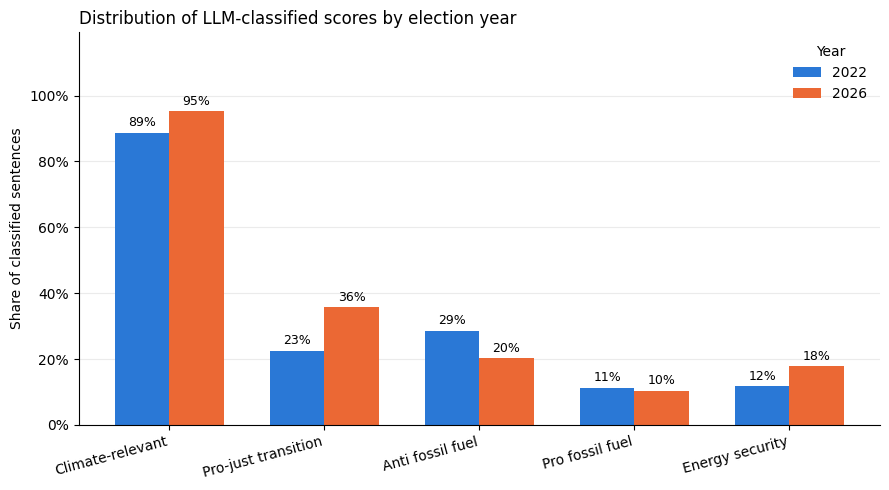

Saved: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\llm_score_distribution_by_year.png


In [ ]:



import matplotlib.pyplot as plt
from matplotlib.patches import Patch
llm_output_path = COMPARISON_DIR / "0.8_score_input_llm_output.xlsx"
llm_df = pd.read_excel(llm_output_path)

# "relevant" is the three-way relevance call (relevant / not relevant / not sure); the
# other four are independent 0/1 category flags. Recoding relevance to 0/1 puts all five
# scores on the same "share of sentences" scale so they can share one axis.
SCORE_LABELS = {
    "relevant_flag": "Climate-relevant",
    "pro_just_transition": "Pro-just transition",
    "anti_ff": "Anti fossil fuel",
    "pro_ff": "Pro fossil fuel",
    "energy_security": "Energy security",
}
llm_df["relevant_flag"] = (llm_df["relevant"] == "relevant").astype(int)

share_by_year = (
    llm_df.groupby("year")[list(SCORE_LABELS)]
    .mean()
    .reindex(columns=list(SCORE_LABELS))
)
counts_by_year = llm_df.groupby("year").size()
print(f"{len(llm_df)} classified sentences: " + ", ".join(f"{y}={n}" for y, n in counts_by_year.items()))
display(share_by_year.rename(columns=SCORE_LABELS))

fig, ax = plt.subplots(figsize=(9, 5))
score_labels = list(SCORE_LABELS.values())
x_positions = range(len(score_labels))
bar_width = 0.35
# Color is assigned by year (the entity), not by which bar is taller, so the mapping
# stays fixed regardless of which year scores higher on a given category.
year_colors = {2022: "#2a78d6", 2026: "#eb6834"}

for offset, year in zip((-1, 1), sorted(share_by_year.index)):
    values = share_by_year.loc[year] * 100
    positions = [xi + offset * bar_width / 2 for xi in x_positions]
    ax.bar(positions, values, width=bar_width, color=year_colors[year], label=str(year))
    for pos, value in zip(positions, values):
        ax.text(pos, value + 1, f"{value:.0f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x_positions))
ax.set_xticklabels(score_labels, rotation=15, ha="right")
ax.set_ylabel("Share of classified sentences")
ax.set_ylim(0, max(share_by_year.to_numpy().max() * 100 * 1.25, 10))
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0f}%")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_title("Distribution of LLM-classified scores by election year", loc="left", fontsize=12)
ax.legend(title="Year", frameon=False, loc="upper right")
fig.tight_layout()

score_dist_path = COMPARISON_DIR / "llm_score_distribution_by_year.png"
fig.savefig(score_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {score_dist_path}")

386 classified sentences: 2022=213, 2026=173
Total sentences per year: {2022: 2667, 2026: 2395}


C:\Users\charlott\AppData\Local\Temp\ipykernel_32036\2961808718.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.07086614173228346' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  share_by_year.loc[year] = share_by_year.loc[year] / total_sentences_per_year[year]
C:\Users\charlott\AppData\Local\Temp\ipykernel_32036\2961808718.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.01799775028121485' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  share_by_year.loc[year] = share_by_year.loc[year] / total_sentences_per_year[year]
C:\Users\charlott\AppData\Local\Temp\ipykernel_32036\2961808718.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.022872140982

,Climate-relevant,Pro-just transition,Anti fossil fuel,Pro fossil fuel,Energy security
year,,,,,
2022,0.070866,0.017998,0.022872,0.008999,0.009374
2026,0.068894,0.025887,0.014614,0.007516,0.012944


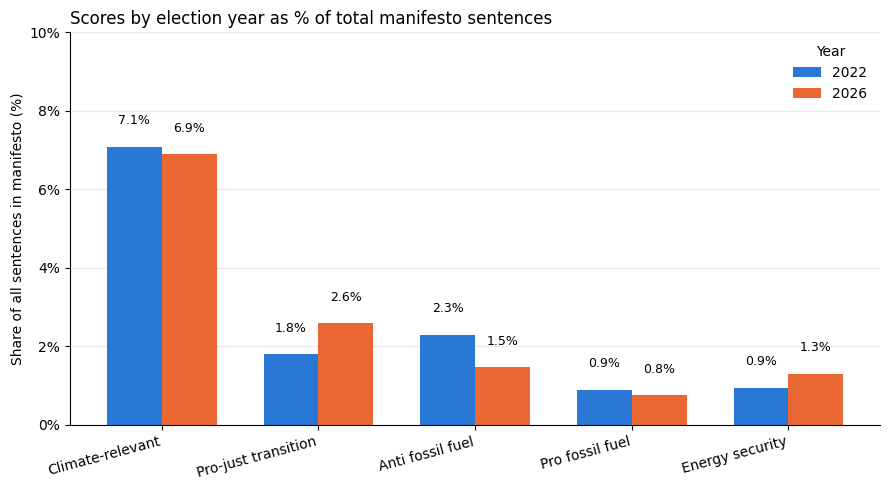

Saved: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\llm_score_distribution_by_year.png


In [ ]:
llm_df["relevant_flag"] = (llm_df["relevant"] == "relevant").astype(int)

# Total sentences per year in the manifestos
total_sentences_per_year = {2022: 2667, 2026: 2395}

# Count sentences with each score for each year
score_counts_by_year = llm_df.groupby("year")[list(SCORE_LABELS)].sum()

# Calculate share of ALL sentences in manifesto
share_by_year = score_counts_by_year.copy()
for year in share_by_year.index:
    share_by_year.loc[year] = share_by_year.loc[year] / total_sentences_per_year[year]

share_by_year = share_by_year.reindex(columns=list(SCORE_LABELS))

counts_by_year = llm_df.groupby("year").size()
print(f"{len(llm_df)} classified sentences: " + ", ".join(f"{y}={n}" for y, n in counts_by_year.items()))
print(f"Total sentences per year: {total_sentences_per_year}")
display(share_by_year.rename(columns=SCORE_LABELS))

fig, ax = plt.subplots(figsize=(9, 5))
score_labels = list(SCORE_LABELS.values())
x_positions = range(len(score_labels))
bar_width = 0.35
year_colors = {2022: "#2a78d6", 2026: "#eb6834"}

for offset, year in zip((-1, 1), sorted(share_by_year.index)):
    values = share_by_year.loc[year] * 100
    positions = [xi + offset * bar_width / 2 for xi in x_positions]
    ax.bar(positions, values, width=bar_width, color=year_colors[year], label=str(year))
    for pos, value in zip(positions, values):
        ax.text(pos, value + 0.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x_positions))
ax.set_xticklabels(score_labels, rotation=15, ha="right")
ax.set_ylabel("Share of all sentences in manifesto (%)")
ax.set_ylim(0, max(share_by_year.to_numpy().max() * 100 * 1.25, 10))
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0f}%")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_title("Scores by election year as % of total manifesto sentences", loc="left", fontsize=12)
ax.legend(title="Year", frameon=False, loc="upper right")
fig.tight_layout()

score_dist_path = COMPARISON_DIR / "llm_score_distribution_by_year.png"
fig.savefig(score_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {score_dist_path}")

In [ ]:
# Running from START HERE skips the extraction/classification cells above, so
# summary_df will not exist yet - reload the combined summary this notebook already
# saved to disk instead of requiring the full pipeline to be re-run.
if "summary_df" not in globals():
    summary_df = pd.read_csv(COMPARISON_DIR / "policlim_manifesto_summary_all_years.csv")

llm_output_path = COMPARISON_DIR / "0.8_score_input_llm_output.xlsx"
llm_df = pd.read_excel(llm_output_path)

# "relevant" is the three-way relevance call (relevant / not relevant / not sure); the
# other four are independent 0/1 category flags. Recoding relevance to 0/1 puts all five
# scores on the same "share of sentences" scale so they can share one axis.
SCORE_LABELS = {
    "relevant_flag": "Climate-relevant",
    "pro_just_transition": "Pro-just transition",
    "anti_ff": "Anti fossil fuel",
    "pro_ff": "Pro fossil fuel",
    "energy_security": "Energy security",
}
llm_df["relevant_flag"] = (llm_df["relevant"] == "relevant").astype(int)

# Manifesto-level LLM sentence counts, to compare against the policlim scores in
# summary_df. llm_df only holds the high-score (>=0.8) subset that was sent for LLM
# classification, so counting (not averaging) within that subset and dividing by the
# manifesto's full sentence_count below puts these on the same "share of all sentences
# in the manifesto" scale as climate_salience_share, instead of "share of the subset".
llm_manifesto_scores = (
    llm_df.groupby(["year", "manifesto"], as_index=False)[list(SCORE_LABELS)]
    .sum()
    .rename(columns=SCORE_LABELS)
)

# llm_df's "manifesto" labels were typed by hand during the export step and may not
# spell candidate/party names exactly as summary_df's "label" does, so match each one
# to the closest label within the same year rather than requiring an exact string match.
from difflib import get_close_matches

labels_by_year = summary_df.groupby("year")["label"].unique().apply(list).to_dict()

def best_label_match(name, year, cutoff=0.6):
    matches = get_close_matches(name, labels_by_year.get(year, []), n=1, cutoff=cutoff)
    return matches[0] if matches else None

llm_manifesto_scores["matched_label"] = [
    best_label_match(name, year)
    for name, year in zip(llm_manifesto_scores["manifesto"], llm_manifesto_scores["year"])
]

unmatched = llm_manifesto_scores[llm_manifesto_scores["matched_label"].isna()]
if not unmatched.empty:
    print("No close label match found for:")
    print(unmatched[["year", "manifesto"]].to_string(index=False))

# One row per manifesto, with the policlim score sitting next to the LLM-derived scores.
policlim_vs_llm = summary_df.merge(
    llm_manifesto_scores.drop(columns="manifesto"),
    left_on=["year", "label"],
    right_on=["year", "matched_label"],
    how="left",
).drop(columns="matched_label")

for col in SCORE_LABELS.values():
    policlim_vs_llm[col] = policlim_vs_llm[col] / policlim_vs_llm["sentence_count"]

SCORE_COLUMNS = ["climate_salience_share", "mean_climate_score", *SCORE_LABELS.values()]

# --- Weight scores by each candidate's national vote share -----------------
# 2026 has a municipio-level file with actual vote counts, so its national vote
# share can be computed directly. 2022 only has a district-level SHARE per
# candidate (no absolute vote counts or district totals) locally, so it cannot be
# aggregated into a true national share yet; those rows are left unweighted.
votes_2026 = pd.read_excel(
    PROJECT_ROOT.parent.parent / "data" / "electoral" / "raw" / "primera_vuelta_2026" / "MUNICIPIO_PRESIDENTE_31-05-2026.xlsx"
)
national_votes_2026 = votes_2026.groupby("DES_CAN")["NUM_VOT"].sum()
vote_share_2026 = national_votes_2026 / national_votes_2026.sum()

# manifesto label (policlim) -> DES_CAN (election data candidate). The label does not
# always name the 2026 candidate - e.g. the Pacto Historico manifesto is still labelled
# after Petro, but Cepeda is the 2026 candidate - so this was confirmed by cross-
# referencing each manifesto PDF against the DES_PAR party column, not by name matching.
MANIFESTO_TO_CANDIDATE_2026 = {
    "Pacto Histórico (Petro's party)": "IVÁN CEPEDA CASTRO",
    "Claudia López": "CLAUDIA LÓPEZ",
    "De la Espriella": "ABELARDO DE LA ESPRIELLA",
    "Plan Integrado de Gobierno": "PALOMA VALENCIA LASERNA",
    "Dignidad y Compromiso": "SERGIO FAJARDO VALDERRAMA",
}

policlim_vs_llm["vote_share"] = [
    vote_share_2026.get(MANIFESTO_TO_CANDIDATE_2026.get(label)) if year == 2026 else pd.NA
    for year, label in zip(policlim_vs_llm["year"], policlim_vs_llm["label"])
]
for col in SCORE_COLUMNS:
    policlim_vs_llm[f"{col}_x_vote_share"] = policlim_vs_llm[col] * policlim_vs_llm["vote_share"]

comparison_output_path = COMPARISON_DIR / "policlim_vs_llm_manifesto_scores.csv"
policlim_vs_llm.to_csv(comparison_output_path, index=False, encoding="utf-8-sig")
print(f"Saved: {comparison_output_path}")
display(policlim_vs_llm[["year", "label", "vote_share", *SCORE_COLUMNS, *(f"{c}_x_vote_share" for c in SCORE_COLUMNS)]])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\charlott\\Dropbox (Personal)\\Green_Backlash_Colombia\\data\\manifestos\\output\\policlim_comparison\\0.8_score_input_llm_output.xlsx'

In [ ]:
# Reopen saved outputs and create the high-score TXT export without re-running the classifier.
# Run the save cell above first; this cell only reads the saved CSV/JSON artifacts.
reloaded_sentence_frames = []
reloaded_summaries = {}
reloaded_metadata = {}

for year in YEARS:
    output_dir = OUTPUT_DIRS[year]
    sentence_output = output_dir / f"policlim_{year}_sentence_predictions.csv"
    summary_output = output_dir / f"policlim_{year}_manifesto_summary.csv"
    metadata_output = output_dir / f"policlim_{year}_run_metadata.json"

    required_outputs = [sentence_output, summary_output, metadata_output]
    missing_outputs = [path for path in required_outputs if not path.exists()]
    if missing_outputs:
        raise FileNotFoundError(
            "Run the save cell above first; missing output(s): "
            + ", ".join(str(path) for path in missing_outputs)
        )

    reloaded_sentence_frames.append(pd.read_csv(sentence_output))
    reloaded_summaries[year] = pd.read_csv(summary_output)
    reloaded_metadata[year] = json.loads(metadata_output.read_text(encoding="utf-8"))

reloaded_sentences_df = pd.concat(reloaded_sentence_frames, ignore_index=True)
HIGH_SCORE_THRESHOLD = 0.8
HIGH_SCORE_EXPORT_PATH = COMPARISON_DIR / "0.8_score_input_llm.txt"
high_score_df = (
    reloaded_sentences_df[
        reloaded_sentences_df["climate_score"] >= HIGH_SCORE_THRESHOLD
    ]
    .sort_values(
        ["climate_score", "year", "sentence_number"],
        ascending=[False, True, True],
    )
)

print(f"Reopened {len(reloaded_sentence_frames)} sentence CSVs, "
      f"{len(reloaded_summaries)} summary CSVs, and "
      f"{len(reloaded_metadata)} metadata JSON files")
print(f"{len(high_score_df):,}/{len(reloaded_sentences_df):,} sentences have "
      f"climate_score >= {HIGH_SCORE_THRESHOLD}")

preamble = (
    f"# Corpus export for LLM classification: sentences with climate_score >= {HIGH_SCORE_THRESHOLD}\n"
    f"# {len(high_score_df)} sentences across the {', '.join(YEARS)} manifestos.\n"
    "# The TEXT of each sentence is in Spanish; the classification tasks and definitions below are in English.\n"
    "# TASK 1: Classify each sentence as relevant, not relevant, or not sure.\n"
    "# Definition: A sentence is relevant if it expresses content related to energy, environment,\n"
    "# minerals, fossil fuels, or climate change, containing keywords such as climatico, ambiente,\n"
    "# naturaleza, carbon, recursos minerales, energia, or gas.\n"
    "# TASK 2: Classify each sentence as one, none, or more of the following four categories.\n"
    "# Assign a category only when its defining claim is present; do not classify based on isolated keywords.\n"
    "# Categories may co-occur only when a sentence makes more than one substantive claim.\n"
    "# pro_just_transition: Statements whose central framing of the energy or environmental transition\n"
    "# is fairness, equity, inclusion, participation, recognition, or justice. This includes a just\n"
    "# energy transition or energy model; the rights, roles, needs, or participation of women, Indigenous,\n"
    "# Afro-descendant, rural, local, or other affected communities; fair distribution of benefits, costs,\n"
    "# employment, or protections; and climate justice. References to la crisis ambiental, cambio climático,\n"
    "# or fighting climate change belong here when they are presented as a collective goal, response, or\n"
    "# justification for a fair, inclusive, or justice-oriented transformation.\n"
    "# pro_just_transition examples from the manifestos:\n"
    "# Example 1: Desde el gobierno nacional y con la activa participación del campesinado, los pueblos indígenas, afrodescendientes, negros, raizales, palenqueros, rrom y la población en general, se apoyará a los municipios en la actualización e implementación de sus instrumentos de planificación cuyo eje sea el respeto por el agua y la diversidad cultural, fomentando la revitalización de las economías locales y propendiendo por la adaptación al cambio climático.\n"
    "# Example 2: Los programas de protección ambiental y empleo garantizado reconocerán a las mujeres como agentes fundamentales en la transformación del campo y el mundo rural, así como el derecho a la ciudad en la vía de mitigación y adaptación al cambio climático y la protección de la biodiversidad.\n"
    "# Example 3: A mi amiga y compañera Susana Muhamad, con su convicción ambientalista y su liderazgo en la defensa de la vida, que nos convoca a asumir la justicia climática como causa común.\n"
    "# Example 4: Un modelo de transición energética incluyente y justo para la gente.\n"
    "# anti_ff: Statements advocating movement away from fossil fuels or extractive dependence in the\n"
    "# energy system. This includes reducing or ending coal, oil, gas, or mineral extraction; relying\n"
    "# mainly on renewable energy sources; or invoking environmental protectionas a reason or objective\n"
    "# of replacing fossil fuels. The defining feature is the change in the energy source or extractive\n"
    "# model, not the social justice framing.\n"
    "# anti_ff examples from the manifestos:\n"
    "# Example 1: Haremos que Colombia transite de una matriz energética primaria, predominantemente fósil, dependiente económicamente del carbón y del petróleo, hacia una diversificada, basada en nuestras potencialidades de energías renovables, las cuales son las mejores fuentes energéticas para enfrentar el cambio climático y fortalecer las capacidades del país para la economía productiva.\n"
    "# Example 2: Nuestro gobierno sentará las bases de esta transición mediante un desescalamiento gradual del modelo extractivista y garantizando la confiabilidad y estabilidad del sistema energético, las fuentes de empleo y los recursos económicos provenientes del sector.\n"
    "# pro_ff: Statements advocating the maintenance, expansion, or recovery of fossil-fuel or mineral\n"
    "# extraction. This includes oil and gas exploration or production, fracking, coal mining, and metal\n"
    "# or mineral mining (gold, copper, silver, rare earths) when extraction is presented as an economic,\n"
    "# public, developmental, or otherwise desirable activity. The defining feature is support for\n"
    "# extraction, regardless of whether the sentence also mentions jobs, revenue, or energy security.\n"
    "# pro_ff examples from the manifestos:\n"
    "# Example 1: Recuperar la exploración y la producción de petróleo y gas con seguridad jurídica y criterio técnico.\n"
    "# Example 2: Desarrollar con sentido de bien público y oportunidad económica estratégica las minerías del oro, el cobre, la plata y las tierras raras.\n"
    "# Example 3: Reactivación de Hidrocarburos. Apoyo al Fracking con responsabilidad.\n"
    "# energy_security: Statements framing the energy or mining sector primarily through reliable supply,\n"
    "# affordability, competitiveness, energy independence, employment, fiscal stability, or economic\n"
    "# continuity. This category concerns the security or economic performance of the system, regardless\n"
    "# of whether the energy source is fossil or renewable. Do not assign it merely because a sentence\n"
    "# mentions energy, and do not treat general opposition to regulation as energy security unless it is\n"
    "# explicitly justified by supply or economic performance.\n"
    "# energy_security example from the manifestos:\n"
    "# Example 1: Colombia no puede seguir tratando el sector minero-energético con prejuicios ideológicos ni improvisación, porque de él dependen la seguridad energética, la competitividad, el empleo, la estabilidad fiscal y una parte decisiva de la inversión regional y social.\n"
    "# Boundary rules: anti_ff requires a move away from fossil fuels or extractive dependence; pro_ff\n"
    "# requires support for extraction; energy_security requires a supply or economic-performance frame;\n"
    "# pro_just_transition requires a justice, inclusion, participation, or affected-community frame.\n"
    "# Do not infer one category from another. A sentence can receive multiple labels only if it explicitly\n"
    "# contains multiple defining frames, such as both a renewable shift (anti_ff) and a justice claim\n"
    "# (pro_just_transition).\n"
    "# Each entry is between <<<SENTENCE START | id=ROW_ID>>> and\n"
    "# <<<SENTENCE END | id=ROW_ID>>>. ROW_ID is the reopened sentence CSV row index, so\n"
    "# classifications can be merged back onto the concatenated saved sentence data by that id.\n"
    "# YEAR and MANIFESTO (candidate/party) are given for identification only - classify on TEXT alone.\n"
)

def render_sentence_blocks(frame):
    rendered_blocks = []
    for row_id, row in frame.iterrows():
        header = [
            f"<<<SENTENCE START | id={row_id}>>>",
            f"ROW_ID: {row_id}",
            f"YEAR: {row['year']}",
            f"MANIFESTO: {row['manifesto_id']}",
            f"SCORE: {row['climate_score']}",
            f"SENTENCE_NUMBER: {row['sentence_number']}",
            "TEXT:",
        ]
        rendered_blocks.append("\n".join(header) + f"\n{row['text']}\n<<<SENTENCE END | id={row_id}>>>")
    return "\n\n".join(rendered_blocks)

with open(HIGH_SCORE_EXPORT_PATH, "w", encoding="utf-8") as f:
    f.write(preamble + "\n" + render_sentence_blocks(high_score_df) + "\n")

validation_dir = PROJECT_ROOT / "validation"
validation_dir.mkdir(parents=True, exist_ok=True)
validation_sample_path = validation_dir / "0.8_score_input_llm_sample25.txt"
validation_sample = high_score_df.sample(n=25, random_state=42)
with open(validation_sample_path, "w", encoding="utf-8") as f:
    f.write(preamble + "\n" + render_sentence_blocks(validation_sample) + "\n")

print(f"Saved: {HIGH_SCORE_EXPORT_PATH}")
print(f"Saved random sample of {len(validation_sample)} TEXT records: {validation_sample_path}")

Reopened 2 sentence CSVs, 2 summary CSVs, and 2 metadata JSON files
386/5,062 sentences have climate_score >= 0.8
Saved: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\0.8_score_input_llm.txt
Saved random sample of 25 TEXT records: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\validation\0.8_score_input_llm_sample25.txt


In [ ]:
# Same high-score subset as above, but exported for a different, single-step LLM task:
# classify each sentence as pro_mining, reformist, contra_mining, or none (mutually
# exclusive), instead of the two-task/multi-label relevance + framing classification above.
REFORMIST_EXPORT_PATH = COMPARISON_DIR / "0.8_score_input_llm_reformist.txt"
reformist_preamble = (
    f"# Corpus export for LLM classification: sentences with climate_score >= {HIGH_SCORE_THRESHOLD}\n"
    f"# {len(high_score_df)} sentences across the {', '.join(YEARS)} manifestos.\n"
    "# The TEXT of each sentence is in Spanish; the classification task and definitions below are in English.\n"
    "# TASK (single step): Classify each sentence into exactly ONE of the following four labels.\n"
    "# pro_mining: Statements that frame the mining-energy sector as a positive force for the\n"
    "# country's economic development, poverty reduction, fiscal revenue, or employment, and that\n"
    "# call for its expansion, continuation, or increased investment. This includes support for\n"
    "# opening new exploration or production licenses, legal/judicial security for mining and\n"
    "# hydrocarbon contracts, fracking, or presenting extraction (coal, oil, gold, or other\n"
    "# minerals) as a desirable, legitimate economic activity in its own right. The defining\n"
    "# feature is unconditional or largely unconditional support for the sector's growth or\n"
    "# continuity, without making that support contingent on structural reform of the model.\n"
    "# pro_mining example from the manifestos:\n"
    "# Example 1: Garantizaremos la exploración y explotación de gas en nuestro territorio (costa adentro y costa afuera) para el beneficio de todos los colombianos.\n"
    "# Example 2: Recuperar la exploración y la producción de petróleo y gas con seguridad jurídica y criterio técnico.\n"
    "# Example 3: Reactivación de Hidrocarburos. Apoyo al Fracking con responsabilidad.\n"
    "# reformist: Statements that neither reject the mining-energy sector outright nor endorse its\n"
    "# unconditional continuation, but call for renegotiating its terms: dialogue between\n"
    "# government, communities, and the sector; correcting historical social, environmental, or\n"
    "# fiscal imbalances; redistributing benefits or royalties more fairly to producing regions;\n"
    "# formalizing informal or small-scale mining while pursuing illegal mining; or making\n"
    "# extraction conditional on stronger environmental licensing, oversight, or social\n"
    "# license. The defining feature is a claim to coexistence and correction — improving how the\n"
    "# sector operates and who benefits from it — rather than expanding it or ending it.\n"
    "# reformist example from the manifestos:\n"
    "# Example 1: Realizaremos un Gran Diálogo Nacional Minero-Energético con el propósito de superar el conflicto social en torno al sector, en función de un desarrollo sostenible que ayude a superar las brechas sociales en Colombia.\n"
    "# Example 2: Diferenciar con claridad entre minería legal y minería criminal, respaldando la inversión formal y la formalización del pequeño minero mientras se persigue a las estructuras ilegales.\n"
    "# contra_mining: Statements advocating a reduction of, or an end to, the country's economic\n"
    "# dependence on fossil-fuel extraction and mining, including phasing out coal, oil, or\n"
    "# large-scale/open-pit mining; refusing new exploration licenses; or replacing the extractive\n"
    "# model with a productive economy based on renewable energy or other non-extractive sectors.\n"
    "# The defining feature is an explicit move away from extraction as the basis of the economy,\n"
    "# not merely reforming how it is managed.\n"
    "# contra_mining example from the manifestos:\n"
    "# Example 1: dejando de lado progresivamente la dependencia del petróleo, el carbón y todo tipo de explotaciones mineras y economías ilegales, así como de los modelos de producción agropecuaria que destruyen la naturaleza y reproducen la pobreza.\n"
    "# Example 2: No se otorgarán nuevas licencias para la exploración de hidrocarburos, ni se permitirá la gran minería a cielo abierto.\n"
    "# none: Sentences that do not fit pro_mining, reformist, or contra_mining.\n"
    "# Boundary rules: [PLACEHOLDER: clarify how to distinguish pro_mining from reformist, and reformist from contra_mining]\n"
    "# Each entry is between <<<SENTENCE START | id=ROW_ID>>> and\n"
    "# <<<SENTENCE END | id=ROW_ID>>>. ROW_ID is the reopened sentence CSV row index, so\n"
    "# classifications can be merged back onto the concatenated saved sentence data by that id.\n"
    "# YEAR and MANIFESTO (candidate/party) are given for identification only - classify on TEXT alone.\n"
)
with open(REFORMIST_EXPORT_PATH, "w", encoding="utf-8") as f:
    f.write(reformist_preamble + "\n" + render_sentence_blocks(high_score_df) + "\n")
print(f"Saved: {REFORMIST_EXPORT_PATH}")


Saved: C:\Users\charlott\Dropbox (Personal)\Green_Backlash_Colombia\data\manifestos\output\policlim_comparison\0.8_score_input_llm_reformist.txt


All 386 sentences classified and merged back with the original metadata (ROW_ID, YEAR, MANIFESTO, SENTENCE_NUMBER, SCORE, TEXT) plus a new CLASSIFICATION column, color-coded by label. A Summary tab gives the label counts:

none: 283
pro_mining: 47
contra_mining: 32
reformist: 24

Note: the boundary-rules placeholder in the source file was left unfilled, so classification relied on the category definitions and worked examples provided. Some borderline sentences (e.g., statements mixing hydrocarbon continuation with clean-energy diversification, or generic energy-transition language without an explicit stance on extraction) required judgment calls consistent with the stated defining features of each category.

In [ ]:
# Overview LaTeX table: pro_mining / reformist / contra_mining counts by party and year.
# Printed only, per request - nothing is written to disk here.
reformist_output_path = COMPARISON_DIR / "0.8_score_output_llm_reformist.xlsx"
reformist_df = pd.read_excel(reformist_output_path)

CATEGORIES = ["pro_mining", "reformist", "contra_mining"]
counts = (
    reformist_df
    .groupby(["YEAR", "MANIFESTO", "CLASSIFICATION"])
    .size()
    .unstack("CLASSIFICATION", fill_value=0)
    .reindex(columns=CATEGORIES, fill_value=0)
    .reset_index()
    .sort_values(["YEAR", "MANIFESTO"])
)

latex_rows = "\n".join(
    f"    {row.YEAR} & {row.MANIFESTO} & {row.pro_mining} & {row.reformist} & {row.contra_mining} \\\\"
    for row in counts.itertuples()
)

latex_table = (
    "\\begin{table}[htbp]\n"
    "  \\centering\n"
    "  \\caption{Pro-mining, reformist, and contra-mining statements by party and year}\n"
    "    \\begin{tabular}{|l|l|c|c|c|}\n"
    "    \\toprule\n"
    "    \\textbf{Year} & \\textbf{Party} & \\textbf{Pro-mining} & \\textbf{Reformist} & \\textbf{Contra-mining} \\\\\n"
    "    \\midrule\n"
    f"{latex_rows}\n"
    "    \\bottomrule\n"
    "    \\end{tabular}%\n"
    "  \\label{tab:mining_stance_by_party_year}%\n"
    "\\end{table}%\n"
)

print(latex_table)


\begin{table}[htbp]
  \centering
  \caption{Pro-mining, reformist, and contra-mining statements by party and year}
    \begin{tabular}{|l|l|c|c|c|}
    \toprule
    \textbf{Year} & \textbf{Party} & \textbf{Pro-mining} & \textbf{Reformist} & \textbf{Contra-mining} \\
    \midrule
    2022 & Fajardo (Centro Esperanza) & 0 & 2 & 5 \\
    2022 & Gutiérrez (Equipo por Colombia) & 22 & 3 & 2 \\
    2022 & Hernández (Liga Anticorrupción) & 2 & 1 & 2 \\
    2022 & Petro (Pacto Histórico) & 1 & 6 & 15 \\
    2026 & Claudia López & 2 & 2 & 0 \\
    2026 & De la Espriella & 7 & 0 & 0 \\
    2026 & Dignidad y Compromiso & 0 & 0 & 0 \\
    2026 & Pacto Histórico (Petro's party) & 3 & 10 & 8 \\
    2026 & Plan Integrado de Gobierno & 10 & 0 & 0 \\
    \bottomrule
    \end{tabular}%
  \label{tab:mining_stance_by_party_year}%
\end{table}%



In [ ]:
# Assign each party-year a single stance: the category with the most coded
# sentences, or "reformist" if two (or all three) categories are tied for the lead.
STANCE_LABELS = {
    "pro_mining": "Pro-mining",
    "reformist": "Reformist",
    "contra_mining": "Contra-mining",
}

def majority_stance(row):
    values = {category: row[category] for category in CATEGORIES}
    top_count = max(values.values())
    leaders = [category for category, count in values.items() if count == top_count]
    if len(leaders) == 1:
        return STANCE_LABELS[leaders[0]]
    return STANCE_LABELS["reformist"]

counts_with_stance = counts.copy()
counts_with_stance["STANCE"] = counts_with_stance.apply(majority_stance, axis=1)

latex_rows = "\n".join(
    f"    {row.YEAR} & {row.MANIFESTO} & {row.pro_mining} & {row.reformist} & {row.contra_mining} & {row.STANCE} \\\\"
    for row in counts_with_stance.itertuples()
)

latex_table_with_stance = (
    "\\begin{table}[htbp]\n"
    "  \\centering\n"
    "  \\caption{Pro-mining, reformist, and contra-mining statements by party and year, with assigned stance}\n"
    "    \\begin{tabular}{|l|l|c|c|c|l|}\n"
    "    \\toprule\n"
    "    \\textbf{Year} & \\textbf{Party} & \\textbf{Pro-mining} & \\textbf{Reformist} & \\textbf{Contra-mining} & \\textbf{Stance} \\\\\n"
    "    \\midrule\n"
    f"{latex_rows}\n"
    "    \\bottomrule\n"
    "    \\end{tabular}%\n"
    "  \\label{tab:mining_stance_by_party_year_labeled}%\n"
    "\\end{table}%\n"
)

print(latex_table_with_stance)


\begin{table}[htbp]
  \centering
  \caption{Pro-mining, reformist, and contra-mining statements by party and year, with assigned stance}
    \begin{tabular}{|l|l|c|c|c|l|}
    \toprule
    \textbf{Year} & \textbf{Party} & \textbf{Pro-mining} & \textbf{Reformist} & \textbf{Contra-mining} & \textbf{Stance} \\
    \midrule
    2022 & Fajardo (Centro Esperanza) & 0 & 2 & 5 & Contra-mining \\
    2022 & Gutiérrez (Equipo por Colombia) & 22 & 3 & 2 & Pro-mining \\
    2022 & Hernández (Liga Anticorrupción) & 2 & 1 & 2 & Reformist \\
    2022 & Petro (Pacto Histórico) & 1 & 6 & 15 & Contra-mining \\
    2026 & Claudia López & 2 & 2 & 0 & Reformist \\
    2026 & De la Espriella & 7 & 0 & 0 & Pro-mining \\
    2026 & Dignidad y Compromiso & 0 & 0 & 0 & Reformist \\
    2026 & Pacto Histórico (Petro's party) & 3 & 10 & 8 & Reformist \\
    2026 & Plan Integrado de Gobierno & 10 & 0 & 0 & Pro-mining \\
    \bottomrule
    \end{tabular}%
  \label{tab:mining_stance_by_party_year_labeled}%
\end{tabl

In [ ]:
# Apply the manual validation corrections recorded in
# validation/0.8_score_input_llm_output_validation.xlsx (sheet "classifications_instruction")
# to the LLM's original 0.8_score_input_llm_output.xlsx classifications, then summarize the
# changes and the model's cell-level accuracy. Nothing is written to disk.
import re

validation_path = PROJECT_ROOT / "validation" / "0.8_score_input_llm_output_validation.xlsx"
validation_df = pd.read_excel(validation_path, sheet_name="classifications_instruction")

INSTRUCTION_COL = "classifications_instructions "
EXPLANATION_COL = "explanation "
CLASSIFICATION_COLUMNS = ["relevant", "pro_just_transition", "anti_ff", "pro_ff", "energy_security"]

INSTRUCTION_PATTERN = re.compile(r"^if\s+row_id\s*==\s*(\d+)\s*,\s*(.*)$")
CLAUSE_PATTERN = re.compile(r"^([A-Za-z_]+)\s*==\s*(.+)$")


def parse_instruction(text):
    match = INSTRUCTION_PATTERN.match(text.strip())
    stated_row_id = int(match.group(1))
    clauses = []
    for clause in match.group(2).split(","):
        clause = clause.strip()
        if not clause:
            continue
        clause_match = CLAUSE_PATTERN.match(clause)
        column, value = clause_match.group(1).strip(), clause_match.group(2).strip()
        if column in ("relevance", "relevant"):
            column = "relevant"
        else:
            value = int(value)
        clauses.append((column, value))
    return stated_row_id, clauses


flagged_rows = validation_df[validation_df[INSTRUCTION_COL].notna()]

corrected_df = validation_df[["row_id", "year", "manifesto", "score", "sentence_number", "text", *CLASSIFICATION_COLUMNS]].copy()
corrected_df = corrected_df.set_index("row_id", drop=False)

# The instruction text's row_id is the correction target, even on the one row where it was
# physically written on a different row (row_id 2412's instruction targets row_id 4698).
change_records = []
id_mismatches = []
for _, row in flagged_rows.iterrows():
    stated_row_id, clauses = parse_instruction(row[INSTRUCTION_COL])
    if stated_row_id != row["row_id"]:
        id_mismatches.append((row["row_id"], stated_row_id))
    target_row = validation_df.loc[validation_df["row_id"] == stated_row_id].iloc[0]
    for column, new_value in clauses:
        old_value = target_row[column]
        change_records.append({
            "row_id": stated_row_id,
            "year": target_row["year"],
            "manifesto": target_row["manifesto"],
            "column": column,
            "old_value": old_value,
            "new_value": new_value,
            "explanation": row[EXPLANATION_COL],
        })
        corrected_df.loc[stated_row_id, column] = new_value

changes_df = pd.DataFrame(change_records)

if id_mismatches:
    print("Note: the instruction written on the following row(s) names a different row_id; "
          "the correction was applied to the row_id stated in the instruction text:")
    for written_on_id, target_id in id_mismatches:
        print(f"  written on row {written_on_id}, applied to row {target_id}")
    print()

# --- Summary table of changes: corrections per classification column ---
total_rows = len(validation_df)
summary_table = (
    changes_df.groupby("column")
    .size()
    .reindex(CLASSIFICATION_COLUMNS, fill_value=0)
    .rename("n_corrections")
    .to_frame()
)
summary_table["accuracy_pct"] = ((total_rows - summary_table["n_corrections"]) / total_rows * 100).round(1)
total_cells = total_rows * len(CLASSIFICATION_COLUMNS)
summary_table.loc["TOTAL (cell-level)"] = [
    len(changes_df),
    round((total_cells - len(changes_df)) / total_cells * 100, 1),
]
summary_table.loc["Rows needing >=1 correction"] = [
    flagged_rows.shape[0],
    round((total_rows - flagged_rows.shape[0]) / total_rows * 100, 1),
]

print(f"Validated sentences: {total_rows}")
print(f"Sentences with at least one correction: {flagged_rows.shape[0]}")
print(f"Individual cell-level corrections: {len(changes_df)}")
print()
print("Summary of changes and model accuracy by classification column:")
print(summary_table)
print()
print("All individual corrections:")
print(changes_df[["row_id", "column", "old_value", "new_value", "explanation"]].to_string(index=False))


Note: the instruction written on the following row(s) names a different row_id; the correction was applied to the row_id stated in the instruction text:
  written on row 2412, applied to row 4698

Validated sentences: 386
Sentences with at least one correction: 59
Individual cell-level corrections: 73

Summary of changes and model accuracy by classification column:
                             n_corrections  accuracy_pct
column                                                  
relevant                               2.0          99.5
pro_just_transition                   26.0          93.3
anti_ff                               16.0          95.9
pro_ff                                18.0          95.3
energy_security                       11.0          97.2
TOTAL (cell-level)                    73.0          96.2
Rows needing >=1 correction           59.0          84.7

All individual corrections:
 row_id              column old_value    new_value                                        

Manual validation of the 386 sentences classified by `0.8_score_input_llm_output.xlsx`, using the corrections recorded in `validation/0.8_score_input_llm_output_validation.xlsx`. 59 sentences needed at least one correction (73 individual cell-level corrections across the 5 classification columns).

| Column | Corrections | Accuracy |
|---|---|---|
| relevant | 2 | 99.5% |
| pro_just_transition | 26 | 93.3% |
| anti_ff | 16 | 95.9% |
| pro_ff | 18 | 95.3% |
| energy_security | 11 | 97.2% |
| **Overall (cell-level)** | **73** | **96.2%** |
| Rows needing >=1 correction | 59 | 84.7% |

Note: the instruction physically written on row_id 2412 names row_id 4698 instead. The correction (anti_ff == 0) was applied to row 4698, as stated in the instruction text, not to row 2412.


In [25]:
# Topic percentage table (share of climate-relevant, high-score sentences flagged for each
# topic), for both years. One table/caption/label, with two panels stacked inside it - 2022
# on top, 2026 below - each panel using only its own parties as columns (no shared/empty
# columns). Built from corrected_df, i.e. the LLM classifications after the manual
# validation corrections above. Printed only.
TOPIC_COLUMNS = ["pro_just_transition", "anti_ff", "pro_ff", "energy_security"]
TOPIC_LABELS = {
    "pro_just_transition": "pro\\_just\\_transition",
    "anti_ff": "anti\\_ff",
    "pro_ff": "pro\\_ff",
    "energy_security": "energy\\_security",
}

PARTY_SHORT_NAMES = {
    2022: {
        "Fajardo (Centro Esperanza)": "Fajardo",
        "Gutiérrez (Equipo por Colombia)": "Gutiérrez",
        "Hernández (Liga Anticorrupción)": "Hernández",
        "Petro (Pacto Histórico)": "Pacto Histórico",
    },
    2026: {
        "Claudia López": "Claudia López",
        "De la Espriella": "De la Espriella",
        "Dignidad y Compromiso": "Dignidad y Compromiso",
        "Pacto Histórico (Petro's party)": "Pacto Histórico",
        "Plan Integrado de Gobierno": "Plan Integrado de Gobierno",
    },
}


def topic_percentage_panel(year):
    year_df = corrected_df[corrected_df["year"] == year]
    short_names = PARTY_SHORT_NAMES[year]
    parties = sorted(short_names, key=lambda full_name: short_names[full_name])

    column_spec = "p{0.15\\textwidth} | C{0.12\\textwidth} | " + " | ".join(
        "C{0.10\\textwidth}" for _ in parties
    )
    header = " & ".join([r"\textbf{Topic}", r"\textbf{All Manifestos}"] + [
        f"\\textbf{{{short_names[party]}}}" for party in parties
    ])

    lines = [
        f"  \\textbf{{{year}}}\\\\[2pt]",
        f"  \\begin{{tabular}}{{{column_spec}}}",
        "  \\toprule",
        f"  {header} \\\\",
        "  \\midrule",
    ]
    for topic in TOPIC_COLUMNS:
        all_pct = year_df[topic].mean() * 100
        cells = [TOPIC_LABELS[topic], f"{all_pct:.1f}\\,\\%"]
        for party in parties:
            party_df = year_df[year_df["manifesto"] == party]
            party_pct = party_df[topic].mean() * 100
            cells.append(f"{party_pct:.1f}\\,\\%")
        lines.append("  " + " & ".join(cells) + r" \\")
    lines.append("  \\bottomrule")
    lines.append("  \\end{tabular}")
    return "\n".join(lines)


table_lines = [
    r"\begin{table}[htbp]",
    r"  \centering",
    r"  \tiny",
    r"  \caption{Topic percentages in all manifestos and specific parties, 2022 and 2026}",
]
for year in (2022, 2026):
    table_lines.append(topic_percentage_panel(year))
    if year == 2022:
        table_lines.append(r"  \vspace{6pt}")
table_lines.append(r"  \label{tab:topic_percentages_by_party_year}")
table_lines.append(r"\end{table}")

print("\n".join(table_lines))


\begin{table}[htbp]
  \centering
  \tiny
  \caption{Topic percentages in all manifestos and specific parties, 2022 and 2026}
  \textbf{2022}\\[2pt]
  \begin{tabular}{p{0.15\textwidth} | C{0.12\textwidth} | C{0.10\textwidth} | C{0.10\textwidth} | C{0.10\textwidth} | C{0.10\textwidth}}
  \toprule
  \textbf{Topic} & \textbf{All Manifestos} & \textbf{Fajardo} & \textbf{Gutiérrez} & \textbf{Hernández} & \textbf{Pacto Histórico} \\
  \midrule
  pro\_just\_transition & 21.1\,\% & 30.4\,\% & 5.0\,\% & 5.3\,\% & 36.3\,\% \\
  anti\_ff & 26.3\,\% & 30.4\,\% & 8.8\,\% & 31.6\,\% & 39.6\,\% \\
  pro\_ff & 15.0\,\% & 0.0\,\% & 32.5\,\% & 15.8\,\% & 3.3\,\% \\
  energy\_security & 12.2\,\% & 8.7\,\% & 17.5\,\% & 10.5\,\% & 8.8\,\% \\
  \bottomrule
  \end{tabular}
  \vspace{6pt}
  \textbf{2026}\\[2pt]
  \begin{tabular}{p{0.15\textwidth} | C{0.12\textwidth} | C{0.10\textwidth} | C{0.10\textwidth} | C{0.10\textwidth} | C{0.10\textwidth} | C{0.10\textwidth}}
  \toprule
  \textbf{Topic} & \textbf{All Man

In [23]:
# Manifesto-level LaTeX table: policlim climate salience and LLM-derived topic shares
# (all as a percentage of each manifesto's total sentence count), by year. Uses the
# comparison table saved above, so it can be run standalone without re-running the
# extraction/classification pipeline. Printed only - nothing is written to disk here.
policlim_vs_llm_path = COMPARISON_DIR / "policlim_vs_llm_manifesto_scores.csv"
policlim_vs_llm_table = pd.read_csv(policlim_vs_llm_path)

# (year, label as it appears in policlim_vs_llm_table) -> the display text this table
# uses for the Manifesto column. The 2026 rows show the actual 2026 candidate surname
# and party (per MANIFESTO_TO_CANDIDATE_2026 above), not the manifesto_id label, since
# the label still names the 2022 candidate/programme the PDF was filed under.
MANIFESTO_ROW_ORDER = [
    (2022, "Hern\u00e1ndez (Liga Anticorrupci\u00f3n)", "Hern\u00e1ndez", "Liga Anticorrupci\u00f3n", False),
    (2022, "Petro (Pacto Hist\u00f3rico)", "Petro", "Pacto Hist\u00f3rico", True),
    (2022, "Guti\u00e9rrez (Equipo por Colombia)", "Guti\u00e9rrez", "Equipo por Colombia", False),
    (2022, "Fajardo (Centro Esperanza)", "Fajardo", "Centro Esperanza", False),
    (2026, "De la Espriella", "De la Espriella", "Defensores de la Patria", True),
    (2026, "Pacto Hist\u00f3rico (Petro's party)", "Cepeda", "Pacto Hist\u00f3rico", False),
    (2026, "Plan Integrado de Gobierno", "Valencia", "Centro Democr\u00e1tico", False),
    (2026, "Dignidad y Compromiso", "Fajardo", "Dignidad y Compromiso", False),
    (2026, "Claudia L\u00f3pez", "L\u00f3pez", "Con Claudia, imparables", False),
]

SCORE_COLUMNS = ["climate_salience_share", "Pro-just transition", "Anti fossil fuel", "Pro fossil fuel", "Energy security"]

rows_latex = []
column_values = {col: [] for col in SCORE_COLUMNS}
for year, label, surname, party, is_starred in MANIFESTO_ROW_ORDER:
    match = policlim_vs_llm_table[
        (policlim_vs_llm_table["year"] == year) & (policlim_vs_llm_table["label"] == label)
    ]
    data_row = match.iloc[0]
    star = "*" if is_starred else ""
    party_cell = f"{party}{star}"
    values = " & ".join(f"{data_row[col] * 100:.1f}" for col in SCORE_COLUMNS)
    rows_latex.append(f"    {year} & {party_cell} & {surname} & {values} \\\\")
    for col in SCORE_COLUMNS:
        column_values[col].append(data_row[col] * 100)

# Unweighted average across the 9 manifesto-year rows above (not weighted by sentence count).
average_values = " & ".join(
    f"\\textbf{{{sum(column_values[col]) / len(column_values[col]):.1f}}}" for col in SCORE_COLUMNS
)
rows_latex.append("    \\midrule")
rows_latex.append(f"     &  & \\textbf{{Average}} & {average_values} \\\\")

latex_table = (
    "\\begin{table}[htbp]\n"
    "  \\centering\n"
    "  \\caption{Manifesto-level climate salience (policlim) and LLM-derived topic shares, "
    "as a percentage of all sentences, 2022 vs 2026}\n"
    "  \\begin{tabular}{|l|l|l|r|r|r|r|r|}\n"
    "    \\toprule\n"
    "    \\textbf{Year} & \\textbf{Party} & \\textbf{Candidate} & \\textbf{Clim score} & \\textbf{Pro-JT} "
    "& \\textbf{Anti fossil fuel} & \\textbf{Pro fossil fuel} & \\textbf{Energy security} \\\\\n"
    "    \\midrule\n"
    + "\n".join(rows_latex) + "\n"
    "    \\bottomrule\n"
    "    \\end{tabular}%\n"
    "  \\label{tab:municipio_manifesto_summary_llm}%\n"
    "\\end{table}%\n"
)

print(latex_table)


\begin{table}[htbp]
  \centering
  \caption{Manifesto-level climate salience (policlim) and LLM-derived topic shares, as a percentage of all sentences, 2022 vs 2026}
  \begin{tabular}{|l|l|l|r|r|r|r|r|}
    \toprule
    \textbf{Year} & \textbf{Party} & \textbf{Candidate} & \textbf{Clim score} & \textbf{Pro-JT} & \textbf{Anti fossil fuel} & \textbf{Pro fossil fuel} & \textbf{Energy security} \\
    \midrule
    2022 & Liga Anticorrupción & Hernández & 3.6 & 0.0 & 1.3 & 0.4 & 0.2 \\
    2022 & Pacto Histórico* & Petro & 12.1 & 4.1 & 4.9 & 0.4 & 0.8 \\
    2022 & Equipo por Colombia & Gutiérrez & 7.6 & 0.6 & 0.9 & 1.7 & 1.4 \\
    2022 & Centro Esperanza & Fajardo & 8.8 & 3.6 & 2.6 & 0.0 & 0.7 \\
    2026 & Defensores de la Patria* & De la Espriella & 8.0 & 0.0 & 0.7 & 3.6 & 2.9 \\
    2026 & Pacto Histórico & Cepeda & 7.2 & 3.5 & 1.7 & 0.1 & 0.7 \\
    2026 & Centro Democrático & Valencia & 11.0 & 0.4 & 1.5 & 3.4 & 3.4 \\
    2026 & Dignidad y Compromiso & Fajardo & 1.8 & 0.9 & 0.0 & 0.0